# 인스타 카트 데이터
- 데이터 : https://www.kaggle.com/competitions/instacart-market-basket-analysis

# 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 한글폰트 지정
plt.rcParams['font.family'] = 'AppleGothic'

# 한글폰트 사용 시 -기호 깨지는 문제 해결
plt.rcParams['axes.unicode_minus']=False

In [2]:
# 경로 설정
base_path = '/Users/jeonseoyeong/Desktop/패스트캠퍼스 20기(파이썬)/팀플/'

# 변수명과 파일명 쌍 정의
file_list = {
    'aisles': 'aisles.csv',
    'order_prior': 'order_products__prior.csv',
    'order_train': 'order_products__train.csv',
    'orders': 'orders.csv',
    'products': 'products.csv',
    'departments': 'departments.csv'
}

# 반복문으로 개별 변수에 할당
for var_name, file_name in file_list.items():
    globals()[var_name] = pd.read_csv(os.path.join(base_path, file_name))


# products = pd.read_excel('products.xlsx')
# aisles = pd.read_excel('aisles.xlsx')
# departments = pd.read_excel('departments.xlsx')
# orders = pd.read_csv('orders.csv')
# order_prior = pd.read_excel('order_products__prior.xlsx')
# order_train = pd.read_excel('order_products__train.xlsx')

In [3]:
# 데이터 확인
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


# 데이터 전처리

In [ ]:
# * aisles.csv : 상품 분류(카테고리)
#     - aisle_id: 고유한 진열대 번호 또는 카테고리 ID
#     - aisle: 해당 ID에 대응하는 상품 분류명 (예: prepared soups salads, dry pasta, beauty 등)
#     - 장바구니 분석 (Market Basket Analysis) → 어떤 진열대(aisle) 상품이 같이 구매되는지 분
#     - 추천 시스템 → 고객이 자주 구매하는 aisle을 기반으로 다른 관련 제품 추천



# * order_products__prior : 고객의 과거 주문 이력
#     - order_id :	주문 번호 (하나의 장바구니를 의미)
#     - product_id :	해당 주문에 담긴 상품의 ID
#     - add_to_cart_order	: 장바구니에 담긴 순서 (1이면 가장 먼저 담은 상품)
#     - reordered	: 이전에 한 번이라도 주문했던 상품인지 여부 (1: 재구매, 0: 최초 구매)

# * orders : 고객의 구매 시점 및 순서를 파악하는 핵심 데이터

#     - order_id : 주문 고유 번호 (이걸로 다른 테이블과 연결됨)
#     - user_id : 고객 ID (추천 시스템에서 매우 중요!)
#     - eval_set :이 주문이 어떤 용도인지: 'prior', 'train', 'test'
#     - order_number	해당 고객의 몇 번째 주문인지 (1부터 시작)
#     - order_dow	요일 정보 (0=일요일, 6=토요일)
#     - order_hour_of_day	주문 시간 (0~23시)
#     - days_since_prior_order	이전 주문 이후 경과일 (첫 주문은 NaN)]
# * products : 상품의 메타 정보를 담고 있는 테이블
#     - product_id	상품 고유 ID (추천 시스템의 핵심 키값)
#     - product_name	상품 이름 (설명, UI 출력 등에 활용)
#     - aisle_id	진열대(소분류) ID → aisles.csv로 매핑 가능
#     - department_id	부서(대분류) ID → departments.csv로 매핑 가능


# * order_products__train : 추천 시스템 모델을 훈련하고 나서 성능을 평가할 때 쓰는 "정답(label)" 역할의 데이터셋  (모델 평가용 !!)

# * departments : 상품의 카테고리

In [7]:
# products 통합 데이터셋(products + aisles + departments)
products_copy = products
products_copy = products_copy.merge(aisles, on='aisle_id', how='left')
products_merged = products_copy.merge(departments, on='department_id', how='left')
products_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
 4   aisle          49688 non-null  object
 5   department     49688 non-null  object
dtypes: int64(3), object(3)
memory usage: 2.3+ MB


In [8]:
# 과거 구매 데이터(order_prior + orders + products + departments)
orders_prior = orders[orders['eval_set'] == 'prior']
prior_df = order_prior.merge(orders_prior, on='order_id', how='left')
prior_df = prior_df.merge(products, on='product_id', how='left')
prior_df = prior_df.merge(departments, on='department_id', how='left')
prior_df = prior_df.merge(aisles, on='aisle_id', how='left')
prior_df

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,department,aisle
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,dairy eggs,eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,produce,fresh vegetables
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,pantry,spices seasonings
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,pantry,oils vinegars
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,pantry,baking ingredients
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32434484,3421083,39678,6,1,25247,prior,24,2,6,21.0,Free & Clear Natural Dishwasher Detergent,74,17,household,dish detergents
32434485,3421083,11352,7,0,25247,prior,24,2,6,21.0,Organic Mini Sandwich Crackers Peanut Butter,78,19,snacks,crackers
32434486,3421083,4600,8,0,25247,prior,24,2,6,21.0,All Natural French Toast Sticks,52,1,frozen,frozen breakfast
32434487,3421083,24852,9,1,25247,prior,24,2,6,21.0,Banana,24,4,produce,fresh fruits


In [19]:
prior_df.isna().sum() 

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
department                0
aisle                     0
dtype: int64

In [10]:
prior_df['days_since_prior_order'] = prior_df['days_since_prior_order'].fillna(0)

In [15]:
prior_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  department              object 
 14  aisle                   object 
dtypes: float64(1), int64(10), object(4)
memory usage: 3.6+ GB


# 주제 선정 EDA

In [46]:
prior_df

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,department,aisle
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,dairy eggs,eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,produce,fresh vegetables
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,pantry,spices seasonings
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,pantry,oils vinegars
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,pantry,baking ingredients
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32434484,3421083,39678,6,1,25247,prior,24,2,6,21.0,Free & Clear Natural Dishwasher Detergent,74,17,household,dish detergents
32434485,3421083,11352,7,0,25247,prior,24,2,6,21.0,Organic Mini Sandwich Crackers Peanut Butter,78,19,snacks,crackers
32434486,3421083,4600,8,0,25247,prior,24,2,6,21.0,All Natural French Toast Sticks,52,1,frozen,frozen breakfast
32434487,3421083,24852,9,1,25247,prior,24,2,6,21.0,Banana,24,4,produce,fresh fruits


## 상품 추천 시스템의 필요성



1. 상품이 한 번 이상은 다양하게 구매되고 있음. 상품 다양성 존재 ->  탐색 의지는 존재

2. 재구매율도 전반적으로 좋음.


3. 소수 인기 상품에 재구매 집중 + 다양한 상품 시도하지만 재구매 적음 (롱테일 문제) -> 재구매 성향이 높아 소비 확장 어려움<br>
고객들은 다양한 상품을 시도하나 재구매는 소수 상품에 집중<br>
→ 추천 시스템으로 롱테일 상품 탐색 촉진하고 충성도 있는 상품 외 새로운 상품 노출 필요<br>


- 고객 측면으로 바라봤을 때,

4. 고객 탐색 피로 (Exploration Fatigue) <br>
상품과 카테고리가 너무 많아서 고객이 원하는 상품을 직접 일일이 고르기 어려움 <br>
5. 고객별 소비 패턴 뚜렷, 개인화 <br>


####   1. 실제로  다양한 상품을 접하고 구매하고 있을까?

 ✅ 인스타카트에는 수천 개 상품이 존재

카테고리별로도 너무 많아서 고객이 일일이 고르기 어려움

특히 모바일 환경에서는 스크롤과 클릭이 불편함

🧠 문제: “사고 싶은 건 있는데, 찾기 귀찮다”
🔑 추천이 필요한 이유: 고객의 ‘탐색 비용’을 줄여주는 것 → UX 개선, 이탈률 감소


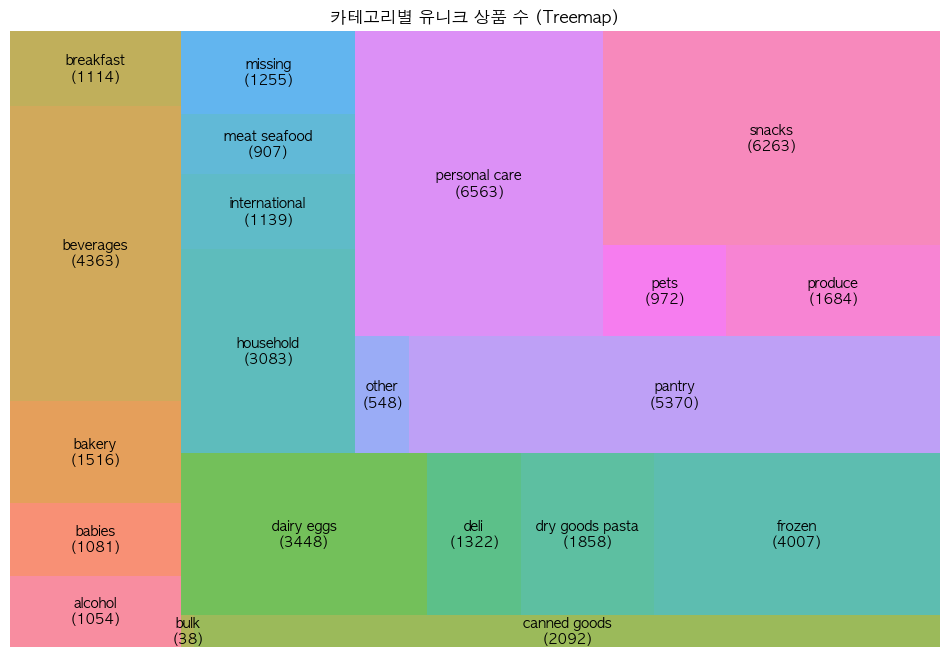

In [247]:
import squarify


# 2. department별 유니크 상품 수 세기
dept_product_counts = prior_df.groupby('department')['product_id'].nunique().reset_index()
dept_product_counts.columns = ['department', 'product_count']

# 3. 라벨 생성
labels = [f"{row['department']}\n({row['product_count']})" for _, row in dept_product_counts.iterrows()]
sizes = dept_product_counts['product_count']

# 4. 트리맵 시각화
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.8,
    color=sns.color_palette('husl', len(labels))  # 파스텔톤 사용
)
plt.title("카테고리별 유니크 상품 수 (Treemap)")
plt.axis('off')
plt.show()  




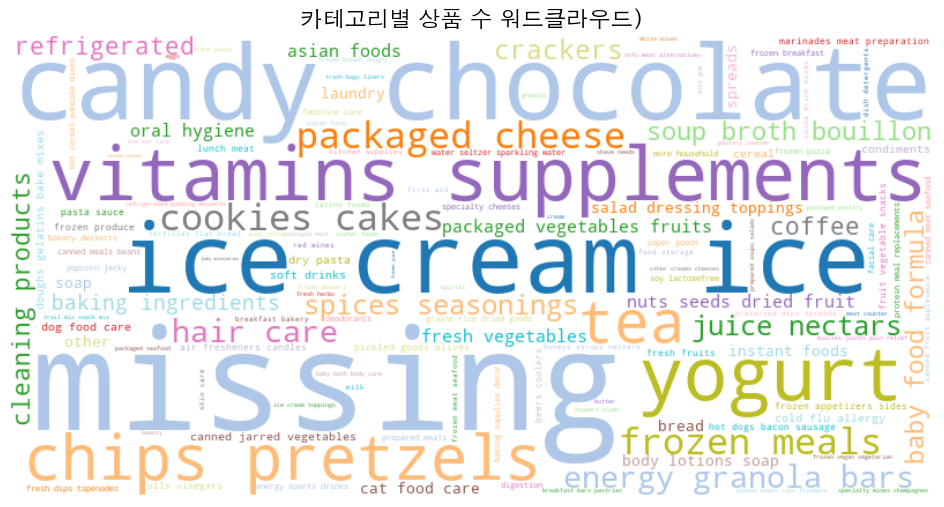

In [75]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 카테고리별 상품 수 dict 생성
wc_dict = prior_df.groupby('aisle')['product_id'].nunique().to_dict()

# 워드클라우드 생성
wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='tab20',  #
    random_state=42
).generate_from_frequencies(wc_dict)

# 시각화
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("카테고리별 상품 수 워드클라우드)", fontsize=16)
plt.show()


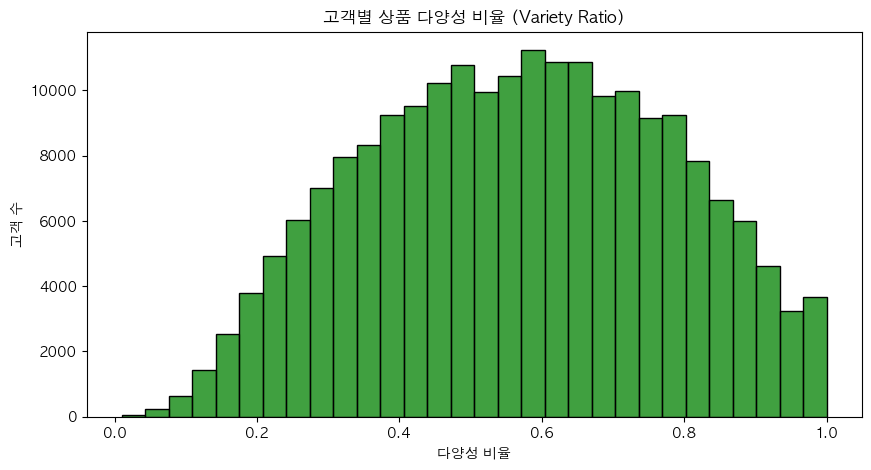

In [30]:
# 고객별 전체 구매 건수
user_total_orders = prior_df.groupby('user_id')['product_id'].count()

# 고객별 서로 다른 상품 수
user_unique_products = prior_df.groupby('user_id')['product_id'].nunique()

# 다양성 지수 = 서로 다른 상품 수 / 총 구매 건수
user_variety_ratio = (user_unique_products / user_total_orders).reset_index()
user_variety_ratio.columns = ['user_id', 'variety_ratio']

# 시각화
plt.figure(figsize=(10,5))
sns.histplot(user_variety_ratio['variety_ratio'], bins=30, color='green')
plt.title('고객별 상품 다양성 비율 (Variety Ratio)')
plt.xlabel('다양성 비율')
plt.ylabel('고객 수')
plt.grid(False)
plt.show()


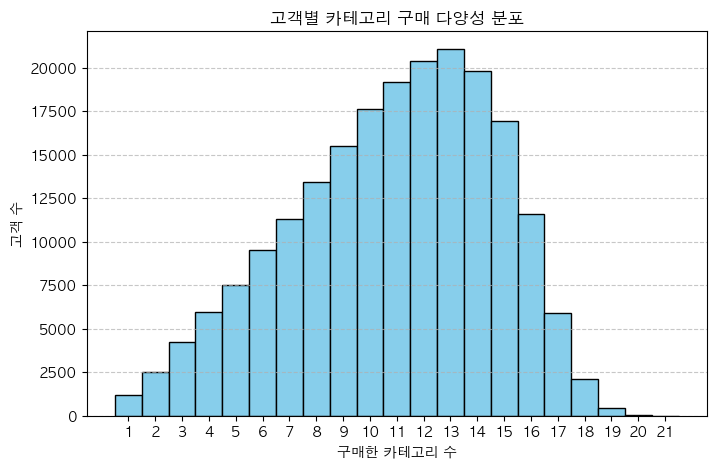

In [33]:
# 1) 고객-카테고리별 구매 건수 집계
user_cat_counts = prior_df.groupby(['user_id', 'department']).size().unstack(fill_value=0)

# 2) 고객별 총 구매 건수
user_total_purchases = user_cat_counts.sum(axis=1)

# 3) 카테고리별 비율 계산
user_cat_ratio = user_cat_counts.div(user_total_purchases, axis=0)

# 4) 다양성 지표 예: 카테고리 수 (비율 > 0인 카테고리 개수)
user_cat_diversity = (user_cat_ratio > 0).sum(axis=1)

# 5) 또는 샤논 다양성 지수(Shannon Diversity Index) 등으로 다양성 측정 가능
import numpy as np
def shannon_entropy(row):
    p = row[row > 0]
    return -np.sum(p * np.log2(p))
user_cat_entropy = user_cat_ratio.apply(shannon_entropy, axis=1)

# 결과 합치기
diversity_df = pd.DataFrame({
    'category_count': user_cat_diversity,
    'category_entropy': user_cat_entropy
})


import matplotlib.pyplot as plt

# 1) 고객-카테고리별 구매 건수 집계
user_cat_counts = prior_df.groupby(['user_id', 'department']).size().unstack(fill_value=0)

# 2) 고객별 총 구매 건수
user_total_purchases = user_cat_counts.sum(axis=1)

# 3) 카테고리별 비율 계산
user_cat_ratio = user_cat_counts.div(user_total_purchases, axis=0)

# 4) 카테고리 다양성 지표: 구매한 카테고리 수 (비율 > 0인 카테고리 개수)
user_cat_diversity = (user_cat_ratio > 0).sum(axis=1)

# 5) 히스토그램 그리기
plt.figure(figsize=(8,5))
plt.hist(user_cat_diversity, bins=range(1, user_cat_diversity.max() + 2), color='skyblue', edgecolor='black', align='left')
plt.title('고객별 카테고리 구매 다양성 분포')
plt.xlabel('구매한 카테고리 수')
plt.ylabel('고객 수')
plt.xticks(range(1, user_cat_diversity.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

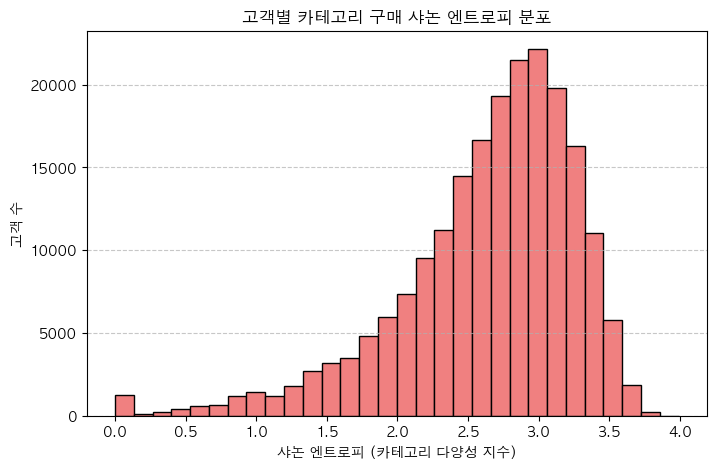

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 고객-카테고리별 구매 건수 집계
user_cat_counts = prior_df.groupby(['user_id', 'department']).size().unstack(fill_value=0)

# 2) 고객별 총 구매 건수
user_total_purchases = user_cat_counts.sum(axis=1)

# 3) 카테고리별 구매 비율 계산 (확률 분포)
user_cat_prob = user_cat_counts.div(user_total_purchases, axis=0)

# 4) 샤논 엔트로피 계산 함수
def shannon_entropy(probs):
    probs = probs[probs > 0]  # 0인 값 제외
    return -np.sum(probs * np.log2(probs))

# 5) 고객별 샤논 엔트로피 계산
user_entropy = user_cat_prob.apply(shannon_entropy, axis=1)

# 6) 히스토그램 그리기
plt.figure(figsize=(8,5))
plt.hist(user_entropy, bins=30, color='lightcoral', edgecolor='black')
plt.title('고객별 카테고리 구매 샤논 엔트로피 분포')
plt.xlabel('샤논 엔트로피 (카테고리 다양성 지수)')
plt.ylabel('고객 수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


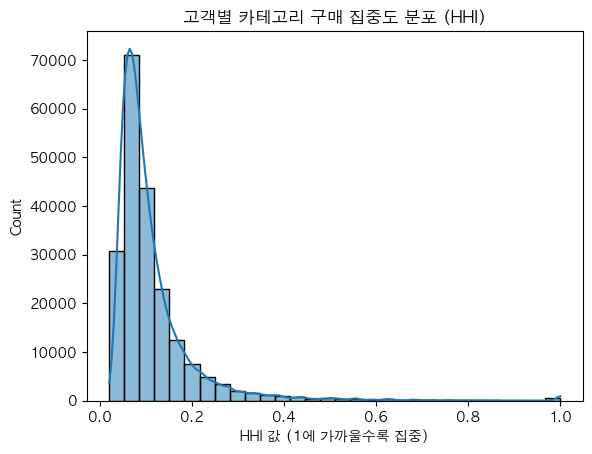

In [204]:
# 고객별 카테고리 구매 횟수 피벗 (예: user_cat_counts)
user_cat_counts = prior_df.pivot_table(index='user_id', columns='aisle', values='product_id', aggfunc='count', fill_value=0)

# 고객별 총 구매 횟수로 나눠서 비율로 변환
user_cat_ratio = user_cat_counts.div(user_cat_counts.sum(axis=1), axis=0)

# HHI 계산
def hhi(row):
    return np.sum(row**2)

user_cat_ratio['HHI'] = user_cat_ratio.apply(hhi, axis=1)

# HHI 분포 시각화
sns.histplot(user_cat_ratio['HHI'], bins=30, kde=True)
plt.title('고객별 카테고리 구매 집중도 분포 (HHI)')
plt.xlabel('HHI 값 (1에 가까울수록 집중)')
plt.show()



판매된 상품 비율: 99.98%


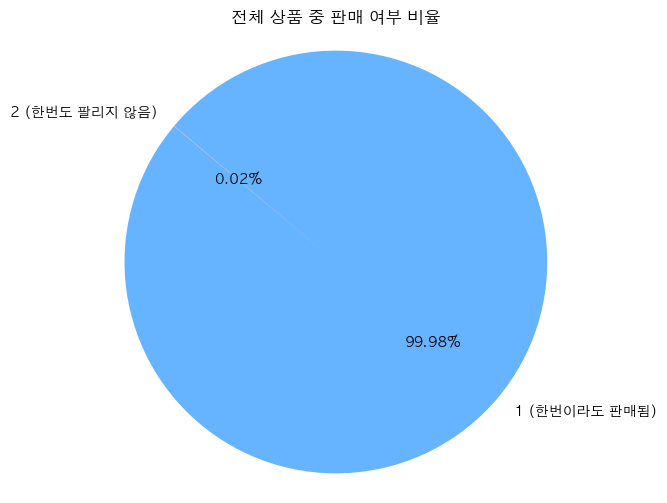

In [35]:
total_products = products['product_id'].nunique()

# 실제로 팔린 상품 수
sold_products = prior_df['product_id'].nunique()
unsold_products = total_products - sold_products

# 비율
sold_ratio = sold_products / total_products
print(f"판매된 상품 비율: {sold_ratio:.2%}")

labels = ['1 (한번이라도 판매됨)', '2 (한번도 팔리지 않음)']
sizes = [sold_products, unsold_products]
colors = ['#66b3ff', '#ff9999']

# 파이차트 그리기
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=140)
plt.title('전체 상품 중 판매 여부 비율')
plt.axis('equal')  # 원형 유지
plt.show()

고객들은 다양한 상품을 경험하고 싶어하는 경향이 있다   =   ‘탐색적 의지’는 존재 !


#### 2. 과연 재구매율은 높은가 ??

재구매 성향이 높아서 소비 확장이 안 됨

✅ 고객은 익숙한 제품만 반복 구매 (→ 재구매 비율 59%, 평균 90회)

하지만 기업 입장에서는 더 많은 상품을 구매하길 원함 (장바구니 확대 전략), 재고관리, 상품순환면에서도 중요.

🧠 문제: “늘 먹는 것만 산다 → 매출 증대 한계”
🔑 추천이 필요한 이유: 고객의 '구매 폭'을 넓혀줌 → up-selling / cross-selling

재구매 비율: 0.5897 (58.97%)
재구매 비율: 0.5897 (58.97%)


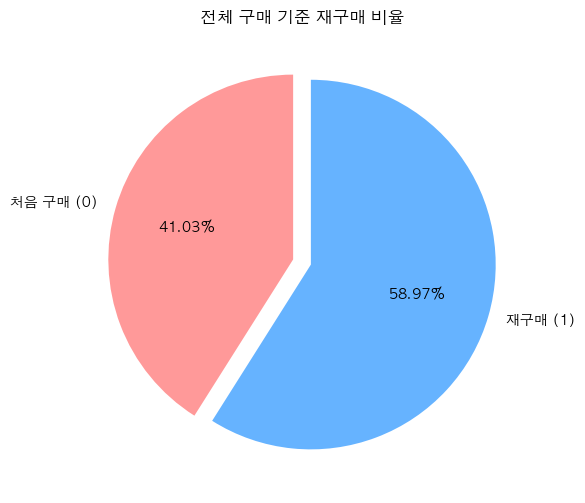

In [124]:
# 전체 구매 횟수 기준 재구매 비율
reorder_rate = prior_df['reordered'].mean()
print(f"재구매 비율: {reorder_rate:.4f} ({reorder_rate*100:.2f}%)")

reorder_rate = prior_df['reordered'].mean()
print(f"재구매 비율: {reorder_rate:.4f} ({reorder_rate*100:.2f}%)")

reorder_counts = prior_df['reordered'].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(reorder_counts, labels= ['처음 구매 (0)', '재구매 (1)'], autopct='%.2f%%', startangle=90, colors=['#ff9999', '#66b3ff'], explode=(0.05, 0.05))
plt.title('전체 구매 기준 재구매 비율')

plt.show()

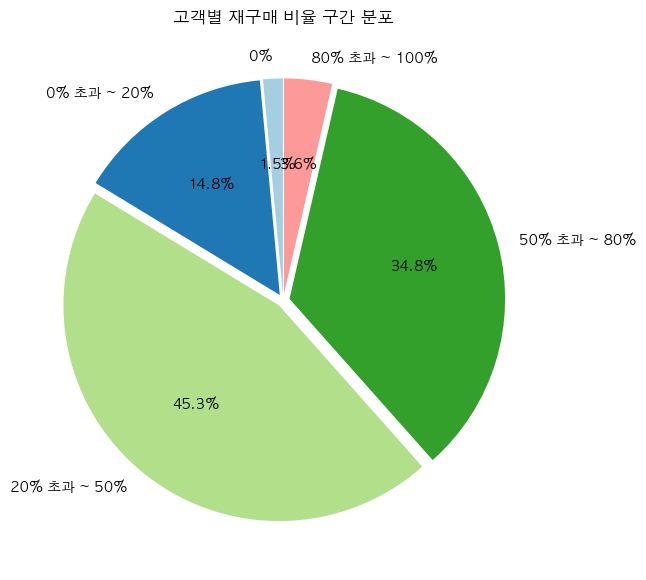

In [128]:
import matplotlib.pyplot as plt
import pandas as pd

# 고객별 재구매 비율 계산 (0~1 사이 값)
reorder_ratio = prior_df.groupby('user_id')['reordered'].mean()

# 0%인 고객 따로 처리
zero_segment = pd.Series(['0%'] * sum(reorder_ratio == 0), index=reorder_ratio[reorder_ratio == 0].index)

# 0% 초과 ~ 100% 고객을 구간으로 나눔
bins = [0.0, 0.2, 0.5, 0.8, 1.0]  # 4개 -> label은 3개
labels = ['0% 초과 ~ 20%', '20% 초과 ~ 50%', '50% 초과 ~ 80%', '80% 초과 ~ 100%']

# 0 초과 고객만 cut으로 구간화
reorder_ratio_segment = pd.cut(
    reorder_ratio[reorder_ratio > 0],
    bins=bins,
    labels=labels,
    include_lowest=False,
    right=True
)

# 두 시리즈 합치기
full_segment = pd.concat([zero_segment, reorder_ratio_segment]).sort_index()

# 구간별 고객 수 집계
segment_counts = full_segment.value_counts().sort_index()


# # 파이차트 시각화
plt.figure(figsize=(7,7))
colors = plt.cm.Paired.colors[:len(segment_counts)]
plt.pie(segment_counts, labels=segment_counts.index, autopct='%.1f%%', startangle=90, colors=colors, explode=[0.03]*len(segment_counts))
plt.title('고객별 재구매 비율 구간 분포')
plt.show()


/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2838/4268015689.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_reorder_ratio = prior_df.groupby('user_id').apply(


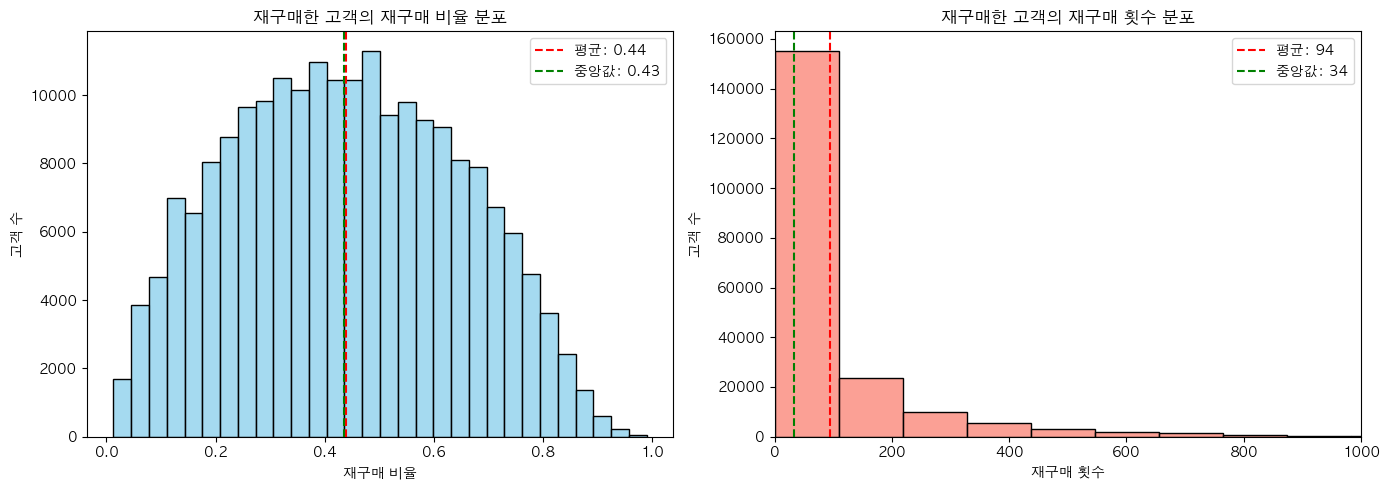

In [22]:
# 고객별 재구매 비율과 재구매 횟수
user_reorder_ratio = prior_df.groupby('user_id').apply(
    lambda x: x['reordered'].sum() / len(x)
)
user_reorder_count = prior_df.groupby('user_id')['reordered'].sum()

# 0보다 큰 값만 필터링 (재구매한 고객만)
filtered_ratio = user_reorder_ratio[user_reorder_ratio > 0]
filtered_count = user_reorder_count[user_reorder_count > 0]

plt.figure(figsize=(14,5))

# 고객별 재구매 비율
plt.subplot(1, 2, 1)
sns.histplot(filtered_ratio, bins=30, color='skyblue')
plt.axvline(filtered_ratio.mean(), color='red', linestyle='--', label=f'평균: {filtered_ratio.mean():.2f}')
plt.axvline(filtered_ratio.median(), color='green', linestyle='--', label=f'중앙값: {filtered_ratio.median():.2f}')
plt.title('재구매한 고객의 재구매 비율 분포')
plt.xlabel('재구매 비율')
plt.ylabel('고객 수')
plt.legend()

# 고객별 재구매 횟수
plt.subplot(1, 2, 2)
sns.histplot(filtered_count, bins=30, color='salmon')
plt.axvline(filtered_count.mean(), color='red', linestyle='--', label=f'평균: {filtered_count.mean():.0f}')
plt.axvline(filtered_count.median(), color='green', linestyle='--', label=f'중앙값: {filtered_count.median():.0f}')
plt.title('재구매한 고객의 재구매 횟수 분포')
plt.xlabel('재구매 횟수')
plt.ylabel('고객 수')
plt.xlim(0, 1000)
plt.legend()

plt.tight_layout()
plt.show()


고객별 재구매 비율
평균: 44% / 중앙값: 43%

분포: 거의 정규분포 형태로, 대다수 고객이 재구매 비율 30~60% 사이에 분포
→ 고객 절반 이상이 전체 구매 중 절반 가까이를 재구매에 사용하고 있음

고객별 재구매 횟수
평균: 93회 / 중앙값: 33회

분포: 0~100회 사이에 몰려 있는 비대칭 분포
→ 일부 충성 고객을 제외하면 대다수 고객이 소수의 상품만 반복 구매


상품 다양성을 확장시키기보다 익숙한 상품을 반복 구매하는 경향

특히 상위 인기 상품 몇 개에 재구매가 집중될 가능성 높음
→ 구매 확장을 유도할 필요가 있음 (신규 상품 추천, 카테고리 다변화 등)



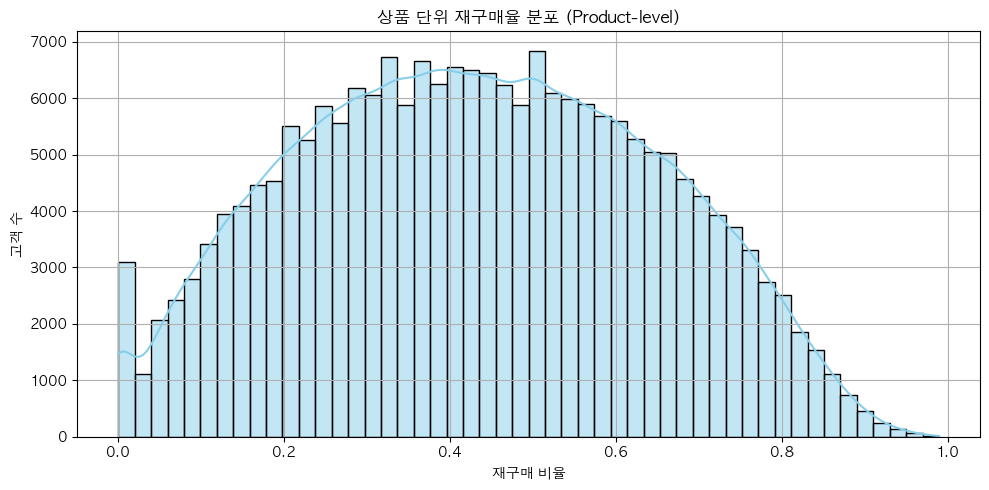

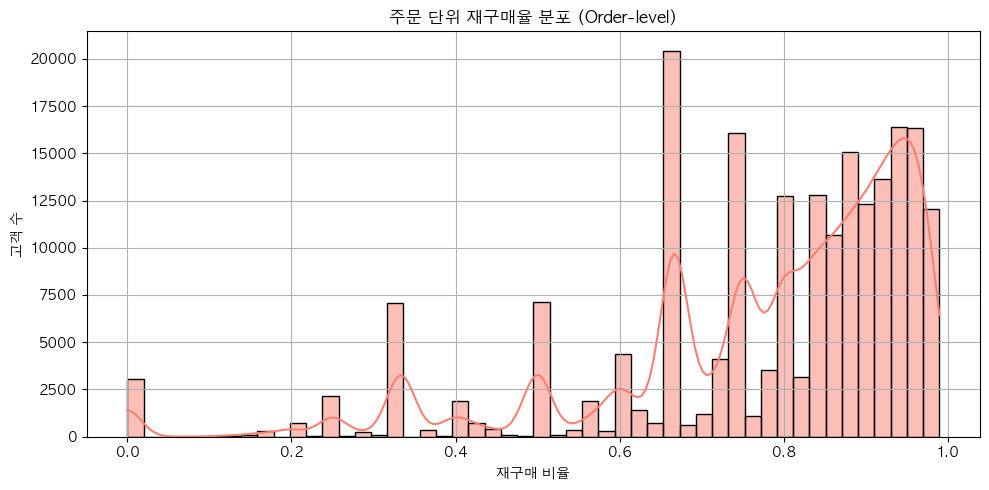

In [330]:
# ((1)) 고객별 총 주문 수 계산

total_order_per_user = prior_df.groupby('user_id')['order_id'].count().reset_index()
total_order_per_user.columns = ['user_id', 'total_order']


# ((2)) 고객별 재구매 건 수 계산

reordered_per_user = prior_df[prior_df['reordered']==1].groupby('user_id')['order_id'].count().reset_index()
reordered_per_user.columns = ['user_id', 'reordered_count']

# 두 데이터 병합
user_reorder = pd.merge(total_order_per_user, reordered_per_user, on='user_id', how='left')
user_reorder['reordered_count'] = user_reorder['reordered_count'].fillna(0)

# 고객별 재구매 비율 계산
user_reorder['product_reorder_ratio'] = user_reorder['reordered_count'] / user_reorder['total_order']

# 결과 확인
user_reorder.head()




### 고객의 주문들 중에서, 재구매 상품이 하나라도 포함된 주문의 비율
## (주문 단위)
# 총 10번 주문했는데, 그중 6번 주문에 재구매 상품이 있음 → 0.6


# 고객별 주문 ID 목록 가져오기
user_order_df = prior_df[['user_id', 'order_id', 'reordered']].drop_duplicates()

# (1) 고객별 총 주문 수
total_order_per_user = user_order_df.groupby('user_id')['order_id'].nunique().reset_index()
total_order_per_user.columns = ['user_id', 'total_orders']

# (2) 재구매 상품이 포함된 주문만 필터링
reordered_orders = user_order_df[user_order_df['reordered'] == 1][['user_id', 'order_id']].drop_duplicates()
reordered_order_count = reordered_orders.groupby('user_id')['order_id'].count().reset_index()
reordered_order_count.columns = ['user_id', 'reordered_orders']

# (3) 병합 후 비율 계산
user_reorder2 = pd.merge(total_order_per_user, reordered_order_count, on='user_id', how='left')
user_reorder2['reordered_orders'] = user_reorder2['reordered_orders'].fillna(0)
user_reorder['order_reorder_ratio'] = user_reorder2['reordered_orders'] / user_reorder2['total_orders']
user_reorder


plt.figure(figsize=(10, 5))
sns.histplot(user_reorder['product_reorder_ratio'], bins=50, kde=True, color='skyblue')
plt.title('상품 단위 재구매율 분포 (Product-level)')
plt.xlabel('재구매 비율')
plt.ylabel('고객 수')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(user_reorder['order_reorder_ratio'], bins=50, kde=True, color='salmon')
plt.title('주문 단위 재구매율 분포 (Order-level)')
plt.xlabel('재구매 비율')
plt.ylabel('고객 수')
plt.grid(True)
plt.tight_layout()
plt.show()

주문 단위로 보면, 고객 대부분은 주문할 때 재구매 상품을 하나 이상 포함함.

하지만 상품 단위로 보면, 재구매율은 대체로 0.3~0.5 수준으로 아주 높지는 않음 <br>
➡️ 고객은 매 주문 시 익숙한 일부 상품을 중심으로, 나머지는 새로운 상품으로 구성하는 경향.
➡️ 즉, 충성도 높은 핵심 상품 + 탐색적 소비의 패턴이 나타남.

#### 파레토 현상(특정 상품에만 소비가 집중되는 현상)이 존재하는가?

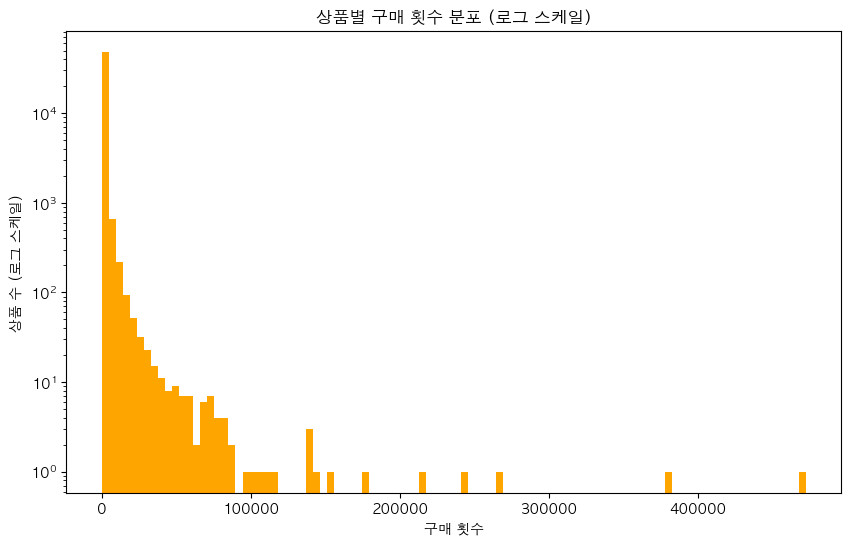

In [61]:
import numpy as np

# 상품별 총 구매 횟수
product_purchase_counts = prior_df['product_id'].value_counts()

plt.figure(figsize=(10,6))
plt.hist(product_purchase_counts, bins=100, color='orange', log=True)  # 로그 스케일 Y축
plt.title("상품별 구매 횟수 분포 (로그 스케일)")
plt.xlabel("구매 횟수")
plt.ylabel("상품 수 (로그 스케일)")
plt.show()


##### 소수 상품에 재구매가 집중됨 (롱테일 문제)

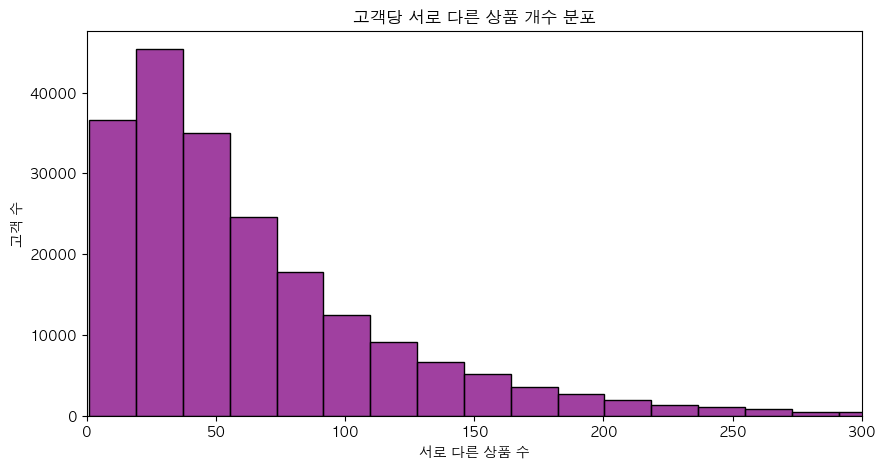

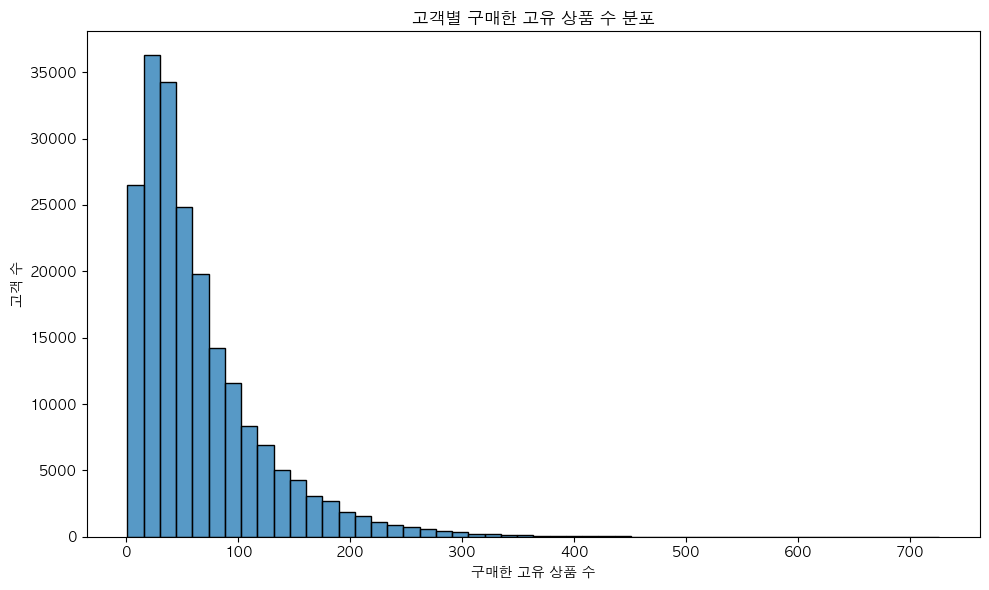

In [51]:
# 고객당 구매한 서로 다른 상품 개수 분포
user_product_variety = prior_df.groupby('user_id')['product_id'].nunique()

plt.figure(figsize=(10,5))
sns.histplot(user_product_variety, bins=40, color='purple')
plt.title('고객당 서로 다른 상품 개수 분포')
plt.xlabel('서로 다른 상품 수')
plt.ylabel('고객 수')
plt.xlim(0, 300)  # 시각적으로 집중 구간 강조
plt.show()

user_product_count = prior_df.groupby('user_id')['product_id'].nunique()
plt.figure(figsize=(10, 6))
sns.histplot(user_product_count, bins=50)
plt.title('고객별 구매한 고유 상품 수 분포')
plt.xlabel('구매한 고유 상품 수')
plt.ylabel('고객 수')
plt.tight_layout()
plt.show()

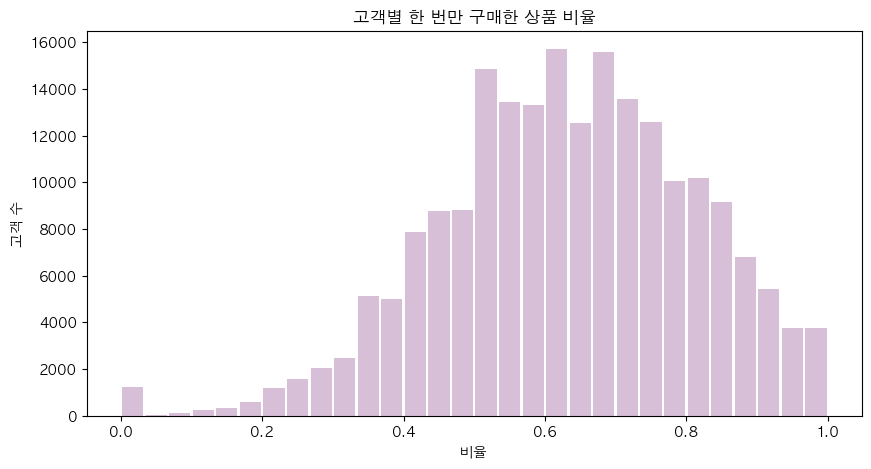

In [61]:
# 고객별 각 상품 구매 횟수
user_product_counts = prior_df.groupby(['user_id', 'product_id'])['order_id'].count().reset_index()
user_product_counts.columns = ['user_id', 'product_id', 'product_order_count']

# 한 번만 구매한 상품
one_time = user_product_counts[user_product_counts['product_order_count'] == 1]

# 고객별 한 번만 구매한 상품 수
one_time_count = one_time.groupby('user_id')['product_id'].count()
total_unique = user_product_counts.groupby('user_id')['product_id'].count()

one_time_ratio = (one_time_count / total_unique).fillna(0).reset_index()
one_time_ratio.columns = ['user_id', 'one_time_ratio']

# 시각화
plt.figure(figsize=(10,5))
sns.histplot(one_time_ratio['one_time_ratio'], bins=30, color='#CBAACB', # 파스텔 보라
    edgecolor=None, linewidth=0, shrink=0.9  )
plt.title('고객별 한 번만 구매한 상품 비율')
plt.xlabel('비율')
plt.ylabel('고객 수')
plt.grid(False)
plt.show()


다양성 비율과 분포가 거의 유사 -> 객들은 비교적 높은 상품 다양성을 보이지만, 그 중 다수는 한 번만 구매하는 상품임 <br>
-> 고객들은 “다양한 상품을 시도”하지만, 재구매까지 이어지는 상품은 극소수라는 뜻!


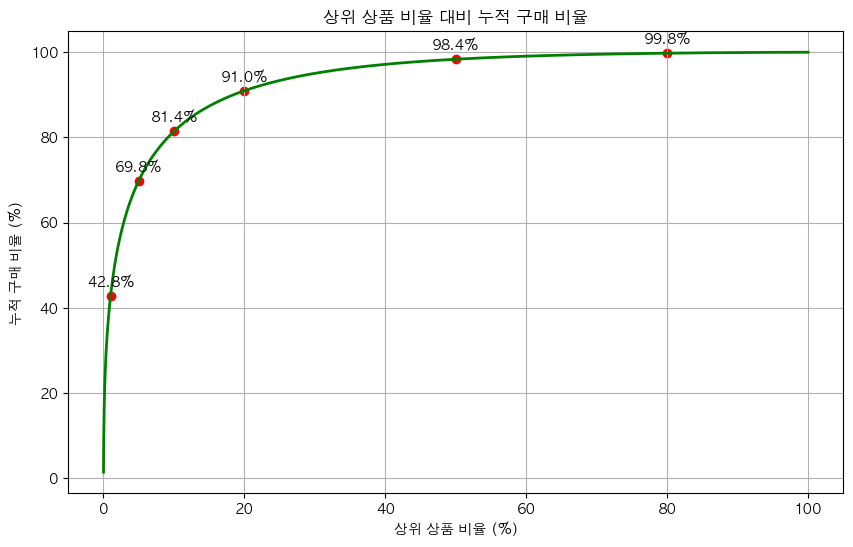

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 상품별 총 구매 횟수 내림차순 정렬
product_purchase_counts = prior_df['product_id'].value_counts()
sorted_counts = product_purchase_counts.sort_values(ascending=False).values

# 2) 누적 구매 횟수 비율 계산
cumulative_ratio = np.cumsum(sorted_counts) / np.sum(sorted_counts)

# 3) x축: 상품 누적 비율 (0~1)
product_ratio = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

# 4) 시각화
plt.figure(figsize=(10,6))
plt.plot(product_ratio * 100, cumulative_ratio * 100, color='green', linewidth=2)
plt.xlabel('상위 상품 비율 (%)')
plt.ylabel('누적 구매 비율 (%)')
plt.title('상위 상품 비율 대비 누적 구매 비율')
plt.grid(True)

# 5) 예시로 20%, 50%, 80% 상위 상품 구매 비율 표시
for p in [1, 5, 10, 20, 50, 80]:
    idx = int(len(sorted_counts) * (p / 100))
    plt.scatter(p, cumulative_ratio[idx]*100, color='red')
    plt.text(p, cumulative_ratio[idx]*100 + 2, f"{cumulative_ratio[idx]*100:.1f}%", ha='center')

plt.show()


상위 20% 상품이 전체 상품의 91%를 차지함 -> "실제로 자주 구매되는 상품은 소수에 불과"
→ 고객은 소수 인기상품 위주로만 쉽게 쇼핑하려 함 -> 추천 시스템을 이용해서 좀 더 다양한 상품을 추천하면 어떨까 ?

Instacart에 등록된 전체 상품은 수천 개 이상이지만
→ 개인 고객이 경험하는 상품은 극히 제한적 
-> 일정한 구매 패턴에 갇혀 있고 익숙한 상품 중심으로 반복 구매하는 소비하고 있음을 의미
-> 추천 시스템을 통해 미경험 상품 탐색을 유도하는 것이 중요

재구매율이 상대적으로 높아서 구매한 상품 다양성은 낮을 줄 알았는데, 생각보다 고객들이 다양한 상품을 구매하고 있다

그러나, 고객들이 "서로 다른 상품을 많이 샀다"는 건 맞지만, 그 다양한 상품들을 ‘한 번만’ 사고 안 산 것일 수 있음.
→ 즉, '재구매 없이 넓게 소비'일 가능성 있음.

재구매율 상위 상품이 포함된 카테고리 수: 21


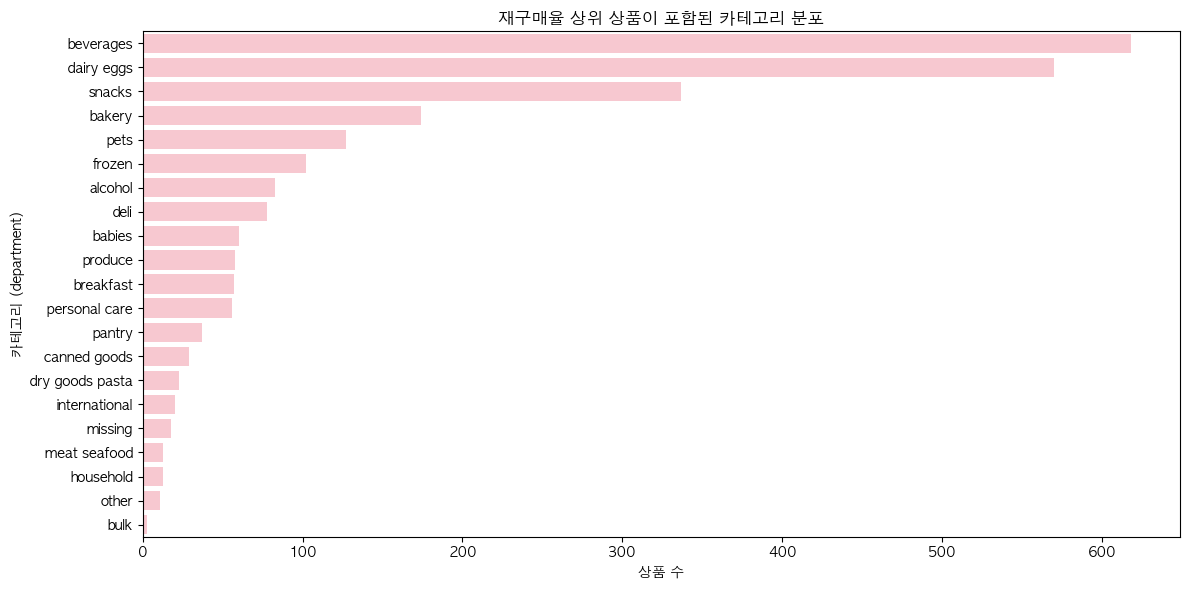

In [64]:
product_reorder_ratio = prior_df.groupby('product_id')['reordered'].mean().reset_index()
product_reorder_ratio.columns = ['product_id', 'reorder_ratio']

threshold = product_reorder_ratio['reorder_ratio'].quantile(0.95)
high_reorder = product_reorder_ratio[product_reorder_ratio['reorder_ratio'] >= threshold]

# product 정보와 병합
high_reorder = pd.merge(high_reorder, products[['product_id', 'department_id']], on='product_id')
# 카테고리 수 세기
num_departments = high_reorder['department_id'].nunique()
print(f"재구매율 상위 상품이 포함된 카테고리 수: {num_departments}")

# 카테고리명도 함께 병합
high_reorder = pd.merge(high_reorder, departments, on='department_id')

plt.figure(figsize=(12,6))
sns.countplot(data=high_reorder, y='department', color = 'pink', order=high_reorder['department'].value_counts().index)
plt.title('재구매율 상위 상품이 포함된 카테고리 분포')
plt.xlabel('상품 수')
plt.ylabel('카테고리 (department)')
plt.tight_layout()
plt.show()


동시에, 재구매율이 높은 카테고리의 다양성도 낮게 나타남 ( 소수의 카테고리에 치우져져 있음)
즉, 소수의 카테고리 안의 소수의 상품들만 재구매가 많이 일어남

# 고객 세그먼트 도출

누군가는 매번 신선식품, 누군가는 간편식 위주 등

다양한 고객 취향을 한 가지 방식으로 커버 불가

🧠 문제: “모두에게 똑같은 걸 보여주면 (랭킹), 아무도 만족 못 한다”
🔑 고객 세그먼트가 필요한 이유: 그룹별 맞춤 → 만족도 + 충성도 증가

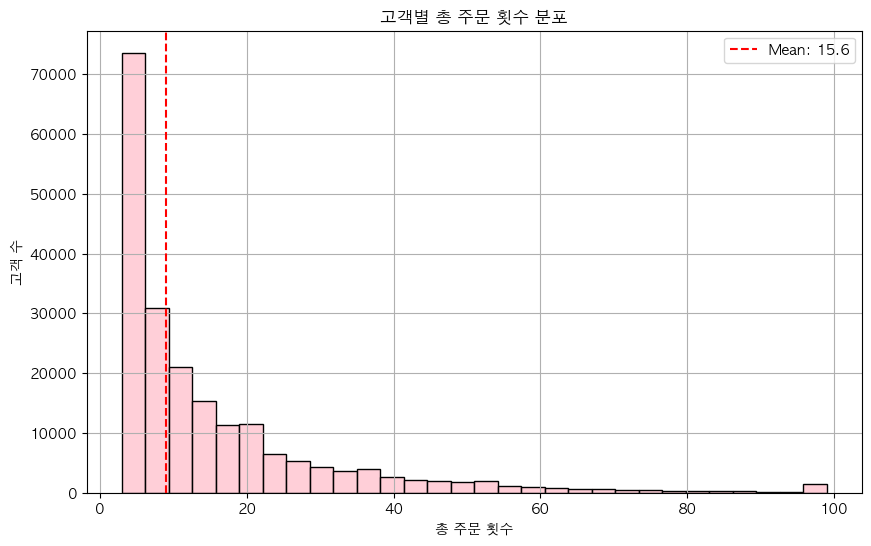

In [73]:
# 고객별 총 주문 횟수 집계
order_counts = orders_prior.groupby('user_id')['order_number'].max()

plt.figure(figsize=(10,6))
sns.histplot(order_counts, bins=30, kde=False, color='pink')
plt.title('고객별 총 주문 횟수 분포')
plt.xlabel('총 주문 횟수')
plt.ylabel('고객 수')
plt.axvline(order_counts.median(), color='red', linestyle='--', label=f'Mean: {order_counts.mean().round(1)}')
plt.legend()
plt.grid(True)
plt.show()

개인화 추천이 가장 이상적인 형태이긴 하지만, Instacart 데이터와 구조에서는 군집 기반 추천이 현실적으로 더 적절하다고 생각함.
* why?
고객수가 너무 많음 <br>
Instacart는 수십만 명의 고객을 보유한 대규모 플랫폼입니다. 이러한 규모에서는 각 고객에게 실시간으로 맞춤형 추천을 제공하려면 막대한 연산 자원과 높은 모델 복잡도가 요구됩니다. 현실적인 리소스와 분석 범위를 고려해볼 때, 더 단순하고 효율적인 방법이 필요하다고 판단
구매 이력 불균형 (Cold-start 문제)<br>
평균 구매 횟수는 15회이지만, 대부분의 고객은 그보다 낮은 구매 이력을 가지고 있고, 일부 소수 고객이 많은 구매를 주도하고 있다.
이처럼 구매 빈도에 있어 편향된 분포가 나타나고 있기 때문에, **유사한 구매 패턴을 보이는 고객 그룹(군집)**을 기반으로 한 추천 전략이 현실적이고 효율적인 접근 방식이라고 판단


## RFM
RFM에서 M(구매금액) 관련 데이터가 없어서 대신 재주문율활용 분석

* R : 마지막 주문 이후 경과일  ->  현재일 - 마지막 주문일
* F : 총 주문 횟수  ->  user_id별 주문 횟수
* M : 총 구매 금액  ->  재구매율 또는 재구매 횟수로 대체

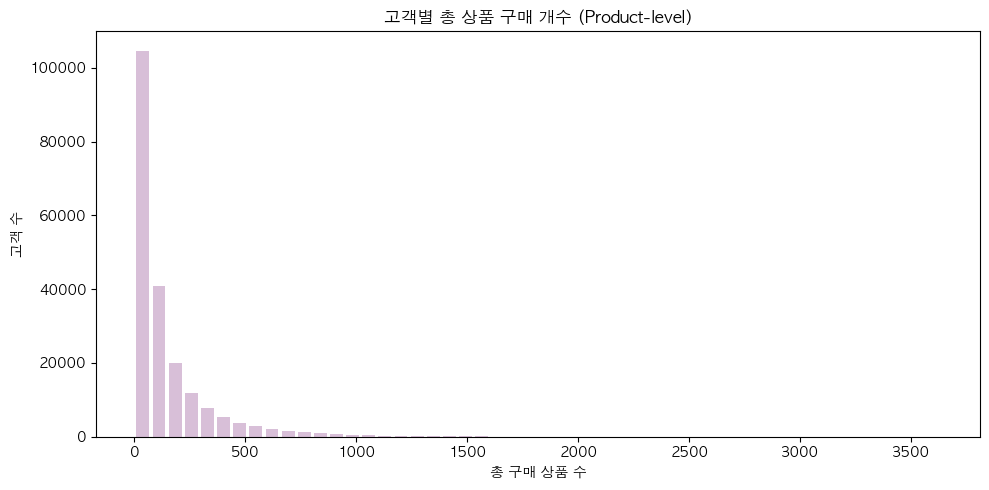

In [100]:
exist_users = prior_df[prior_df['order_number'] != 1]

# 고객별 총 상품 구매 수 계산
user_total_purchases = exist_users.groupby('user_id')['product_id'].count().reset_index()
user_total_purchases.columns = ['user_id', 'total_count']

plt.figure(figsize=(10, 5))
sns.histplot(user_total_purchases['total_count'], bins=50, color='#CBAACB',edgecolor=None,
    shrink=0.8)
plt.title('고객별 총 상품 구매 개수 (Product-level)')
plt.xlabel('총 구매 상품 수')
plt.ylabel('고객 수')
# plt.xlim(0, 1000)
plt.grid(False)
plt.tight_layout()
plt.show()

금액 정보가 없어 총 구매수와 재구매율을 비교한 결과, 분포가 더 안정적인 재구매율을 M항목으로 사용 !
(총 구매수는 너무 한쪽으로 치우친 편중된 분포 ..)

In [86]:

# (1) 고객별 총 주문 수 계산

total_order_per_user = prior_df.groupby('user_id')['order_id'].count().reset_index()
total_order_per_user.columns = ['user_id', 'total_order']


# (2) 고객별 재구매 건 수 계산

reordered_per_user = prior_df[prior_df['reordered']==1].groupby('user_id')['order_id'].count().reset_index()
reordered_per_user.columns = ['user_id', 'reordered_count']

# 두 데이터 병합
user_reorder = pd.merge(total_order_per_user, reordered_per_user, on='user_id', how='left')
user_reorder['reordered_count'] = user_reorder['reordered_count'].fillna(0)

# 고객별 재구매 비율 계산
user_reorder['product_reorder_ratio'] = user_reorder['reordered_count'] / user_reorder['total_order']



orders_copy = orders.copy()
orders_copy = orders_copy[orders_copy['eval_set'] == 'prior']
orders_copy['days_since_prior_order'] = orders_copy['days_since_prior_order'].fillna(0)
orders_copy['order_date'] = orders_copy.groupby('user_id')['days_since_prior_order'].cumsum()

latest_day = orders_copy['order_date'].max()
rfm = orders_copy.groupby('user_id').agg({
    'order_date': lambda x: latest_day - x.max(),  # Recency
    'order_number': 'count'                        # Frequency
}).rename(columns={'order_date': 'Recency', 'order_number': 'Frequency'}).reset_index()

# 2. 이전에 만든 user_reorder (고객별 재구매율) 데이터프레임 불러오기 

# 3. rfm 데이터프레임과 user_reorder 병합
rfm = rfm.merge(user_reorder[['user_id', 'product_reorder_ratio']], on='user_id', how='left')

# 4. 컬럼명 Monetary로 변경
rfm.rename(columns={'product_reorder_ratio': 'Monetary'}, inplace=True)


# 결과 확인
rfm.head()



,user_id,Recency,Frequency,Monetary
0,1,189.0,10,0.694915
1,2,167.0,14,0.476923
2,3,232.0,12,0.625000
3,4,310.0,5,0.055556
4,5,325.0,4,0.378378


##### ****'RFM' vs 'RFM + 파생변수' ****

In [ ]:
## Recency, Frequency, reorder_ratio, avg_cart_size(4가지)
* 상관계수를 보니 avg_cart_size의 다른 변수와의 상관성이 낮게 나타므로 분류 기준으로 활용

In [146]:
#평균 장바구니 크기 (avg_cart_size)
cart_size = prior_df.groupby(['user_id', 'order_id'])['product_id'].count().reset_index()
avg_cart = cart_size.groupby('user_id')['product_id'].mean().reset_index()
avg_cart.columns = ['user_id', 'avg_cart_size']


#구매한 카테고리 다양성 (n_unique_departments)
n_dept = prior_df.groupby('user_id')['department_id'].nunique().reset_index()
n_dept.columns = ['user_id', 'n_unique_departments']

# 유저별 고유 상품 수 
unique_products = prior_df.groupby('user_id')['product_id'].nunique().reset_index(name='distinct_products')

# 평균 주문 간격
avg_days = prior_df.groupby('user_id')['days_since_prior_order'].mean().reset_index(name='avg_days_between_orders')

rfm_df = rfm.merge(avg_days, on='user_id', how='left')
rfm_df = rfm_df.merge(avg_cart, on='user_id', how='left')
rfm_df = rfm_df.merge(n_dept, on='user_id', how='left')


In [148]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def silhouette_compare(rfm_df):
    base_features = ['Recency', 'Frequency', 'Monetary']
    derived_features = ['avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']

    results = {}

    # 기본 RFM만
    X_base = rfm_df[base_features]
    X_base_scaled = StandardScaler().fit_transform(X_base)
    kmeans_base = KMeans(n_clusters=3, random_state=42)
    labels_base = kmeans_base.fit_predict(X_base_scaled)
    score_base = silhouette_score(X_base_scaled, labels_base)
    results['RFM only'] = score_base

    # 파생변수 하나씩 추가
    for feature in derived_features:
        features = base_features + [feature]
        X = rfm_df[features]
        X_scaled = StandardScaler().fit_transform(X)
        kmeans = KMeans(n_clusters=3, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        results[f'RFM + {feature}'] = score

    # 결과 출력
    for k, v in results.items():
        print(f"{k}: Silhouette Score = {v:.4f}")

    return results

# 사용 예시
silhouette_compare(rfm_df)


KeyboardInterrupt: 

** RFM 기반 실루엣 계수 = 0.419 <br>
** RFM + 파생변수 실루엣 계수 = 모두 약 0.3 정도
<br>
따라서 그냥 RFM 기반으로 진행하기로 결정 !!!

In [155]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# # 클러스터링을 위한 데이터 준비
X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 클러스터 수 설정 (예: 3)
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

rfm
# 군집별 요약 통계 출력
cluster_summary = rfm.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
cluster                              
0         288.91       5.73      0.27
1          41.99      48.30      0.71
2         168.71      15.68      0.55


##### **** 왜 나누려는 군집의 수(k)를 3으로 지정했을까? -> 엘보우 메서드

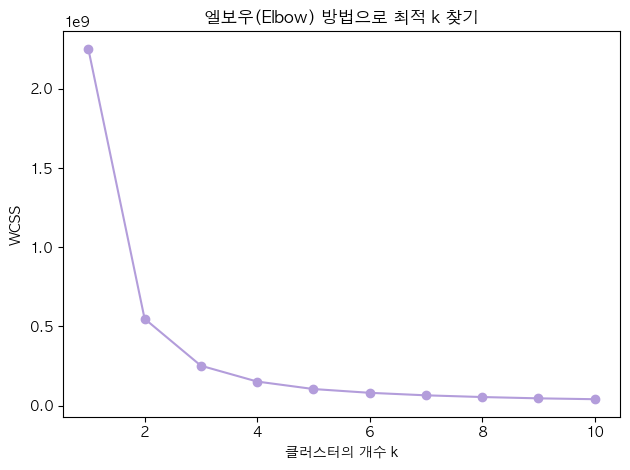

In [90]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wss = []
for k in range(1, 11):
    kmeans_all = KMeans(n_clusters=k, random_state=42)
    kmeans_all.fit(X)  
    wss.append(kmeans_all.inertia_)

plt.plot(range(1, 11), wss, marker='o', color='#b39ddb')  # 연보라 파스텔
plt.xlabel('클러스터의 개수 k')
plt.ylabel('WCSS')
plt.title('엘보우(Elbow) 방법으로 최적 k 찾기')
plt.tight_layout()
plt.show()



* 최적의 k = 그래프에서 급격한 변화가 끝나고 꺾이는 지점
* 엘보우 그래프를 보면 WSS(클러스터 내 제곱합)가 k=1에서 급격히 감소하다가, k=3 근처부터 완만하게 감소하는 형태   
    -> 따라서 최적의 클러스터 수는 k=3으로 판단할 수 있음

##### **** 군집 분석 및 클러스트별 EDA

In [220]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd

def rfm_clustering_only(rfm, n_clusters=3):
    rfm_copy = rfm.copy()

    # 클러스터링을 위한 변수 선택
    X = rfm_copy[['Recency', 'Frequency', 'Monetary']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # KMeans 클러스터링
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    rfm_copy['cluster'] = labels

    # 군집별 요약 통계
    cluster_summary = rfm_copy.groupby('cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

    # 실루엣 점수 계산
    silhouette = silhouette_score(X_scaled, labels)

    return rfm_copy, cluster_summary, silhouette


rfm_clustering_only(rfm, n_clusters=3)
### 실루엣 계수 : 0.41


(        user_id  Recency  Frequency  Monetary  cluster
 0             1    189.0         10  0.694915        2
 1             2    167.0         14  0.476923        2
 2             3    232.0         12  0.625000        2
 3             4    310.0          5  0.055556        0
 4             5    325.0          4  0.378378        0
 ...         ...      ...        ...       ...      ...
 206204   206205    325.0          3  0.250000        0
 206205   206206    116.0         67  0.473684        1
 206206   206207    150.0         16  0.587444        2
 206207   206208      8.0         49  0.707533        1
 206208   206209    155.0         13  0.472868        2
 
 [206209 rows x 5 columns],
          Recency  Frequency  Monetary
 cluster                              
 0         288.91       5.73      0.27
 1          41.99      48.30      0.71
 2         168.71      15.68      0.55,
 0.4187677664630298)

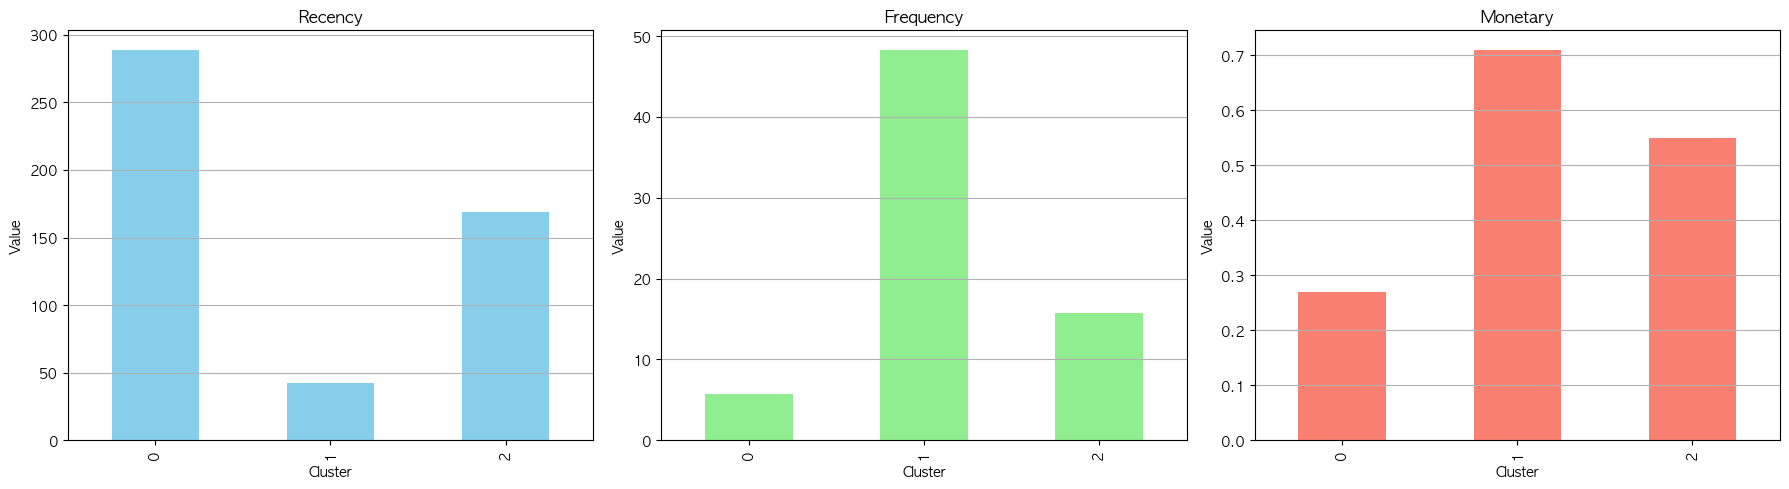

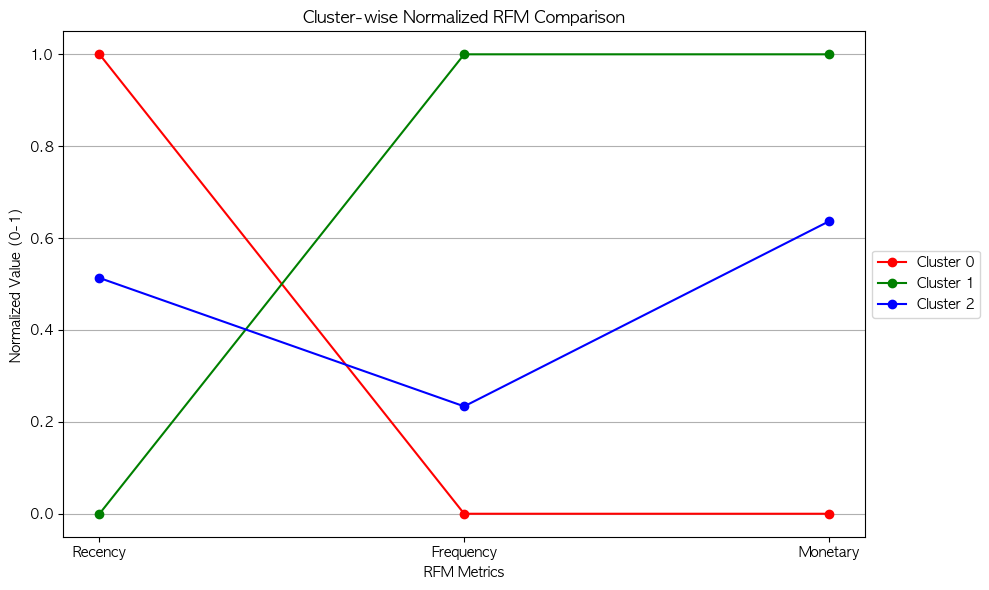

In [111]:
cluster_summary

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_summary['Recency'].plot(kind='bar', ax=axes[0], title='Recency', color='skyblue')
cluster_summary['Frequency'].plot(kind='bar', ax=axes[1], title='Frequency', color='lightgreen')
cluster_summary['Monetary'].plot(kind='bar', ax=axes[2], title='Monetary', color='salmon')

for ax in axes:
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Value')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

for cluster in normalized_df.index:
    plt.plot(['Recency', 'Frequency', 'Monetary'],
             normalized_df.loc[cluster],
             marker='o',
             label=f'Cluster {cluster}',
             color=colors[cluster])

plt.title('Cluster-wise Normalized RFM Comparison')
plt.xlabel('RFM Metrics')
plt.ylabel('Normalized Value (0-1)')
plt.grid(axis='y')

# 범례 오른쪽 바깥으로 이동
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()



Recency : 마지막 구매 시점과 현재와의 거리
Frequency : 몇 번 주문했는가 “총 주문 횟수”에 초점
Monentary : 재주문율

cluster 0 : 이탈 가능성 고객
cluster 1 : 우수 고객 (충성 고객)
cluster 2 : 일반고객

cluster
0    100443
2     75696
1     30070
Name: count, dtype: int64


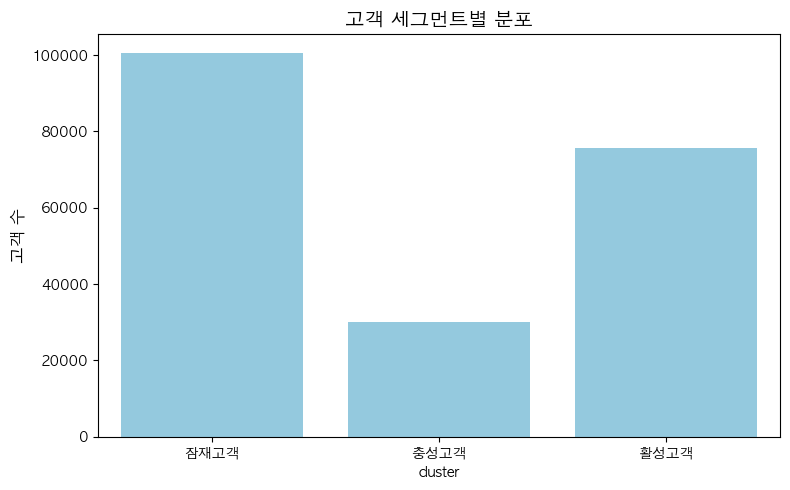

In [121]:
print(rfm['cluster'].value_counts())

plt.figure(figsize=(8, 5))
sns.barplot(
    x=segment_counts.index, 
    y=segment_counts.values, 
    color='skyblue'
)

# 라벨 변경
plt.xticks(ticks=[0, 1, 2], labels=['잠재고객', '충성고객', '활성고객'])

plt.title('고객 세그먼트별 분포', fontsize=14)
plt.ylabel('고객 수', fontsize=12)
plt.tight_layout()
plt.show()


In [125]:
# prior_df 복사본 만들기
prior_df_copy = prior_df.copy()

# rfm 데이터프레임에 cluster 컬럼이 있어야 함
# 군집 정보(user_id, cluster)를 prior_df_copy에 병합
cluster_df = prior_df_copy.merge(rfm[['user_id', 'cluster']], on='user_id', how='left')



In [126]:
# 군집별 요일 분포

dow_summary = cluster_df.groupby(['cluster', 'order_dow']).size().unstack(fill_value=0)
dow_ratio = dow_summary.div(dow_summary.sum(axis=1), axis=0)
# print(dow_ratio)

# 군집별 시간대 분포
hour_summary = cluster_df.groupby(['cluster', 'order_hour_of_day']).size().unstack(fill_value=0)
hour_ratio = hour_summary.div(hour_summary.sum(axis=1), axis=0)
# print(hour_ratio)



#4. 군집별 카테고리(aisle) 선호도

aisle_summary = cluster_df.groupby(['cluster', 'aisle']).size().unstack(fill_value=0)
aisle_ratio = aisle_summary.div(aisle_summary.sum(axis=1), axis=0)
# print(aisle_ratio)



In [41]:
## 클러스터별 시간+요일별 재준문율
# Top N (예: 상위 5개) 추출
top_n = 5
top_combos = (
    cluster_heatmap
    .sort_values(['cluster', 'ratio'], ascending=[True, False])
    .groupby('cluster')
    .head(top_n)
    .sort_values(['cluster', 'ratio'], ascending=[True, False])
)

# 보기 좋게 정리
top_combos[['cluster', 'order_dow', 'order_hour_of_day', 'ratio']].reset_index(drop=True)



,cluster,order_dow,order_hour_of_day,ratio
0,0,0,15,0.018798
1,0,0,14,0.018751
2,0,0,13,0.018283
3,0,0,12,0.017787
4,0,0,11,0.017658
5,1,1,10,0.018920
6,1,1,9,0.018302
7,1,1,11,0.016507
8,1,0,14,0.015921
9,1,0,13,0.015763


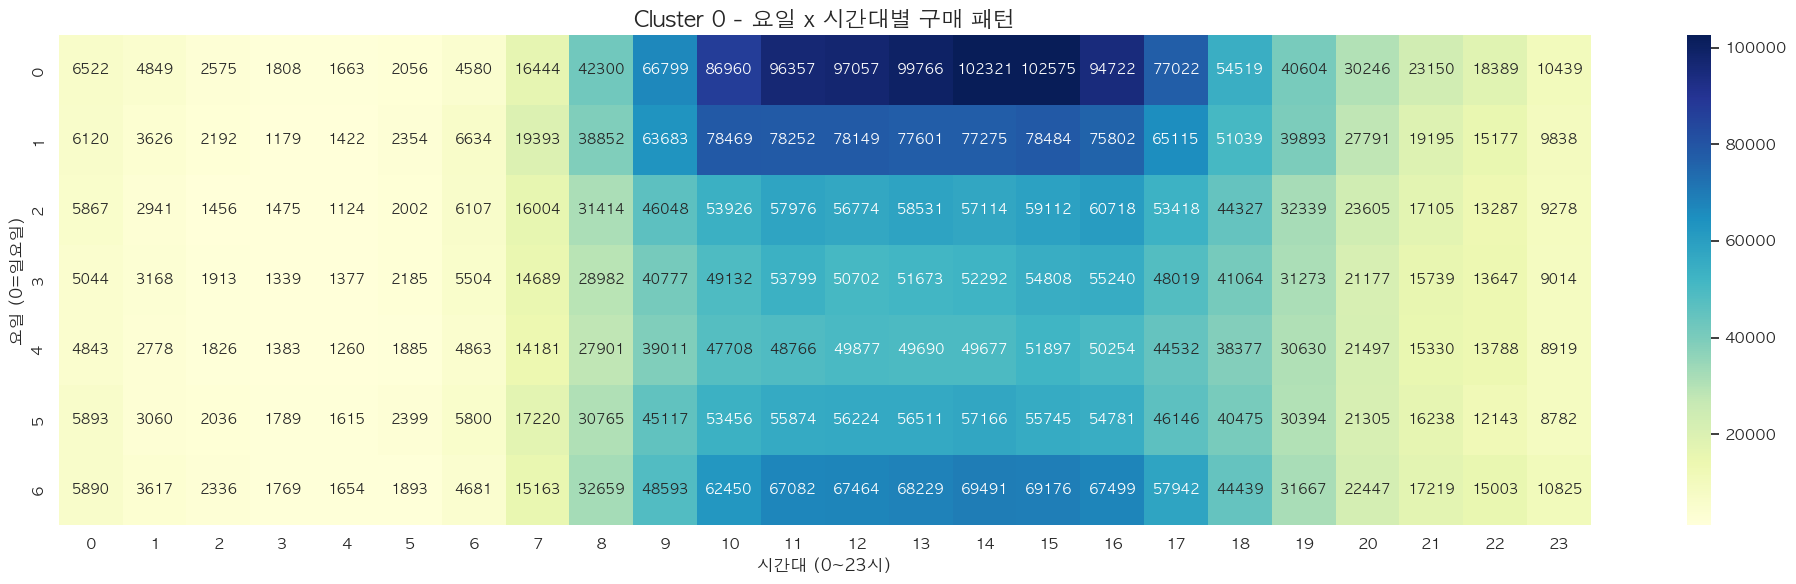

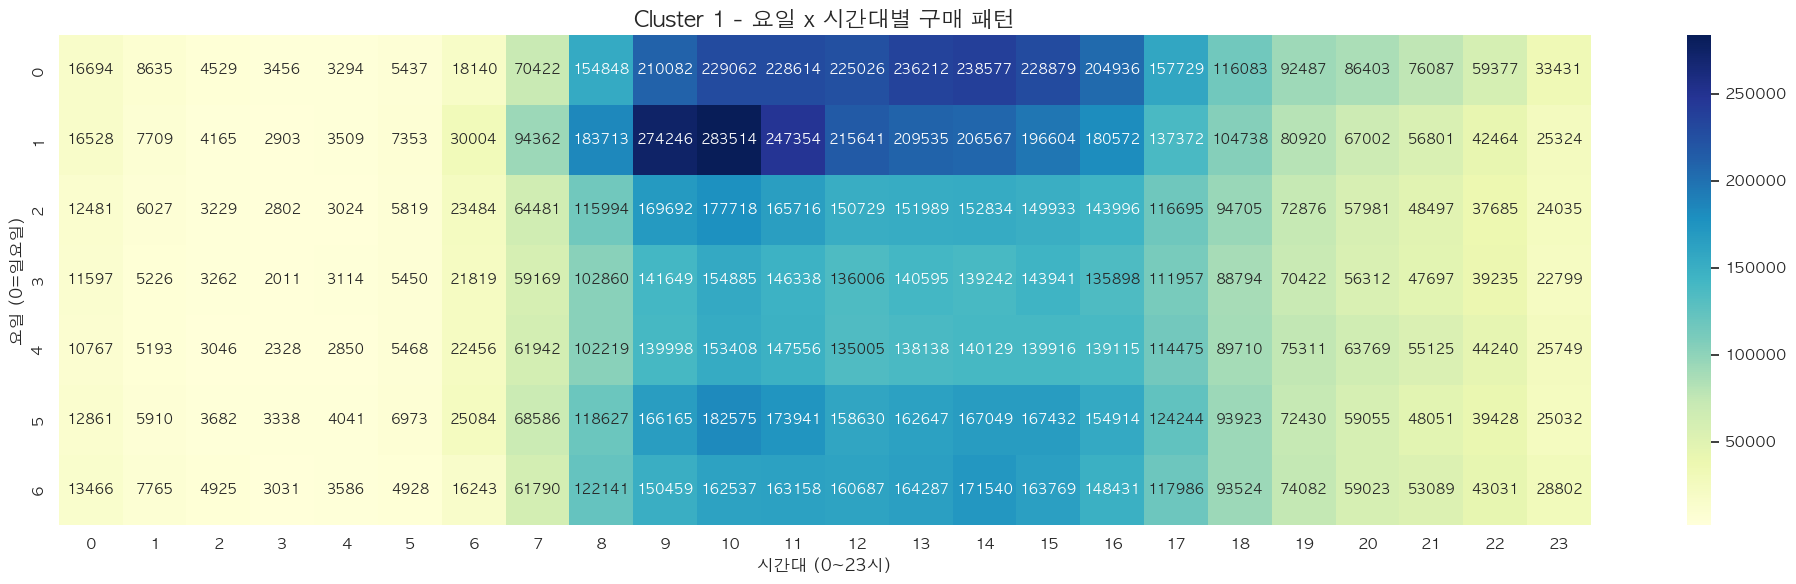

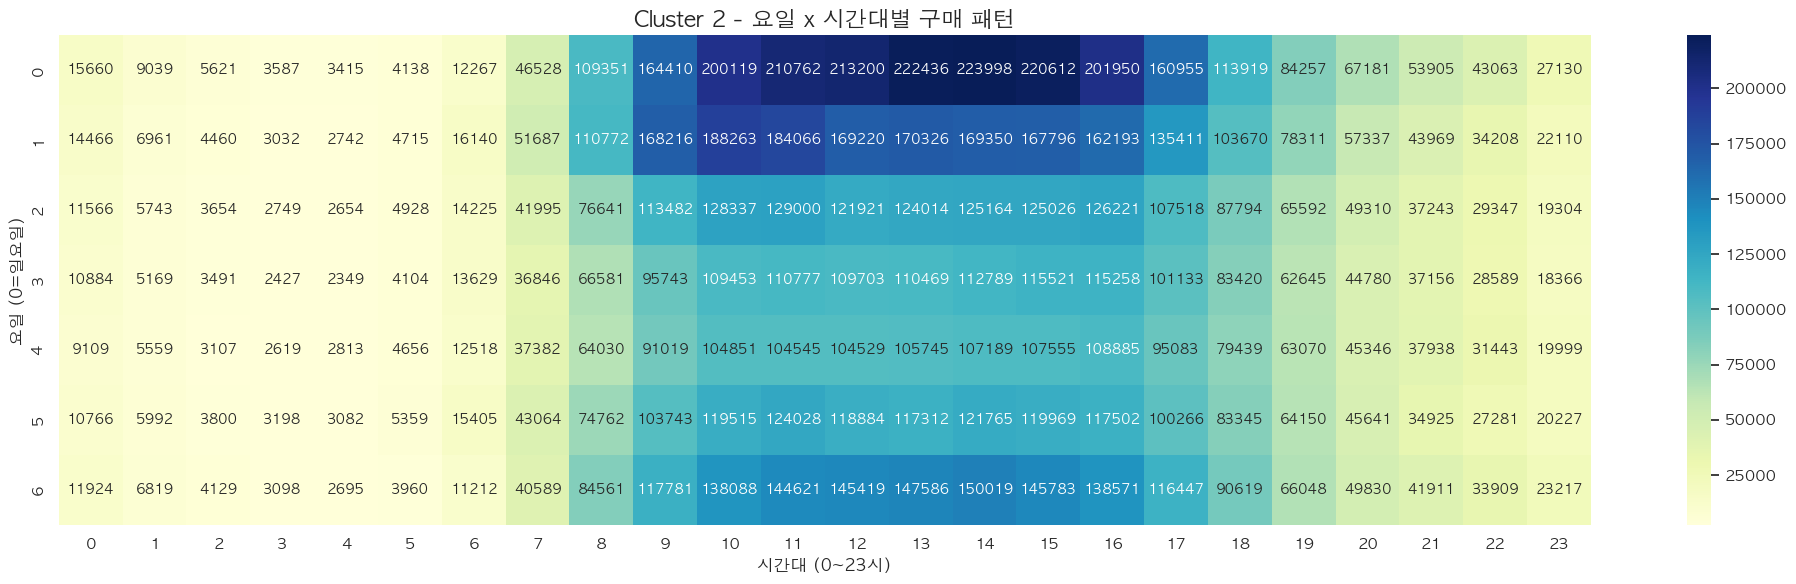

In [215]:
## 클러스터별 시간+요일별 상품 구매 건수

# 군집 번호 가져오기
clusters = cluster_df['cluster'].unique()
clusters.sort()

for cluster in clusters:
    # 해당 군집에 속한 데이터 필터링
    temp = cluster_df[cluster_df['cluster'] == cluster]

    # 요일-시간대별 구매 횟수 집계
    order_heatmap = temp.groupby(['order_dow', 'order_hour_of_day']).size().reset_index(name='count')

    # 피벗테이블로 변환
    order_heatmap_pivot = order_heatmap.pivot(index='order_dow', columns='order_hour_of_day', values='count')

    # 결측값을 0으로 채움
    order_heatmap_pivot = order_heatmap_pivot.fillna(0)

    # 히트맵 시각화
    plt.figure(figsize=(20, 6))
    sns.heatmap(order_heatmap_pivot, cmap='YlGnBu', annot=True, fmt='.0f', annot_kws={'size': 10})

    plt.title(f'Cluster {cluster} - 요일 x 시간대별 구매 패턴', fontsize=16)
    plt.xlabel('시간대 (0~23시)')
    plt.ylabel('요일 (0=일요일)', fontsize=12)
    plt.tight_layout()
    plt.show()



In [ ]:
클러스터 0 (이탈 가능성 고객/ 신규 고객): 일요일 15시에 주문이 가장 많음 → 일 14~15시경 추천 발송


클러스터 1 (우수고객/ 충성고객) : 월요일 오전 9~10시 


클러스터 2 (일반 고객) : 일요일 오후 1~3시 → 일요일 오후 집중 타겟팅

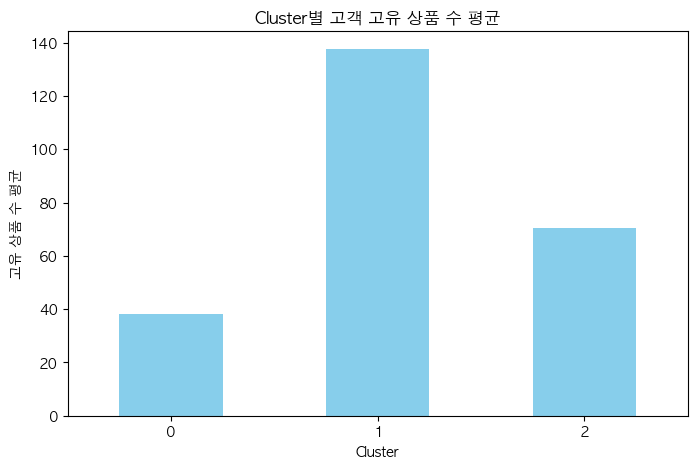

In [128]:
# 3. 군집별 고객 고유 상품 수 평균 막대그래프

unique_products = cluster_df.groupby(['cluster', 'user_id'])['product_id'].nunique().reset_index()
unique_products_mean = unique_products.groupby('cluster')['product_id'].mean()
# print(unique_products_mean)



plt.figure(figsize=(8,5))
unique_products_mean.plot(kind='bar', color='skyblue')
plt.title('Cluster별 고객 고유 상품 수 평균')
plt.xlabel('Cluster')
plt.ylabel('고유 상품 수 평균')
plt.xticks(rotation=0)
plt.show()

고유 상품 수 :
이탈 가능 고객이 가장 적고,
충성 고객이 고유 상품수 종류가 가장 많음
-> 재주문 상품은 믿고 구매 & 인스타카트의 신뢰성을 바탕으로 다양한 제품을 시도하는 양상. 
클러스터 2(충성고객) : 충성도는 높지만 동시에 다양성도 추구하는 고객




클러스터 0 (이탈 가능성 고객):

- if, 일 14~15시 :  전체 베스트셀러(인기상품) 추천 + 해당 시간대 인기 상품 (Produce, Dairy Eggs)
- 그 외의 시간대 : 전체 베스트셀러(인기상품) 추천 


클러스터 1 (우수고객/ 충성고객):
- if, 월 9시~10시 : 재구매율이 높은 상품 + 연관 상품 추천 + top 카테고리 베스트 (좀 다양하게 !!)
- 그 외의 시간대 : 베스트 셀러 추천



클러스터 2 (일반 고객 /  활성 고객):
- if, 일요일 13시 ~ 15시 : 재구매율이 높은 상품 + top 카테고리별 베스트 상품 추천 ((Produce, Dairy Eggs 등)
- 그 외의 시간대 : 베스트 셀러 추천



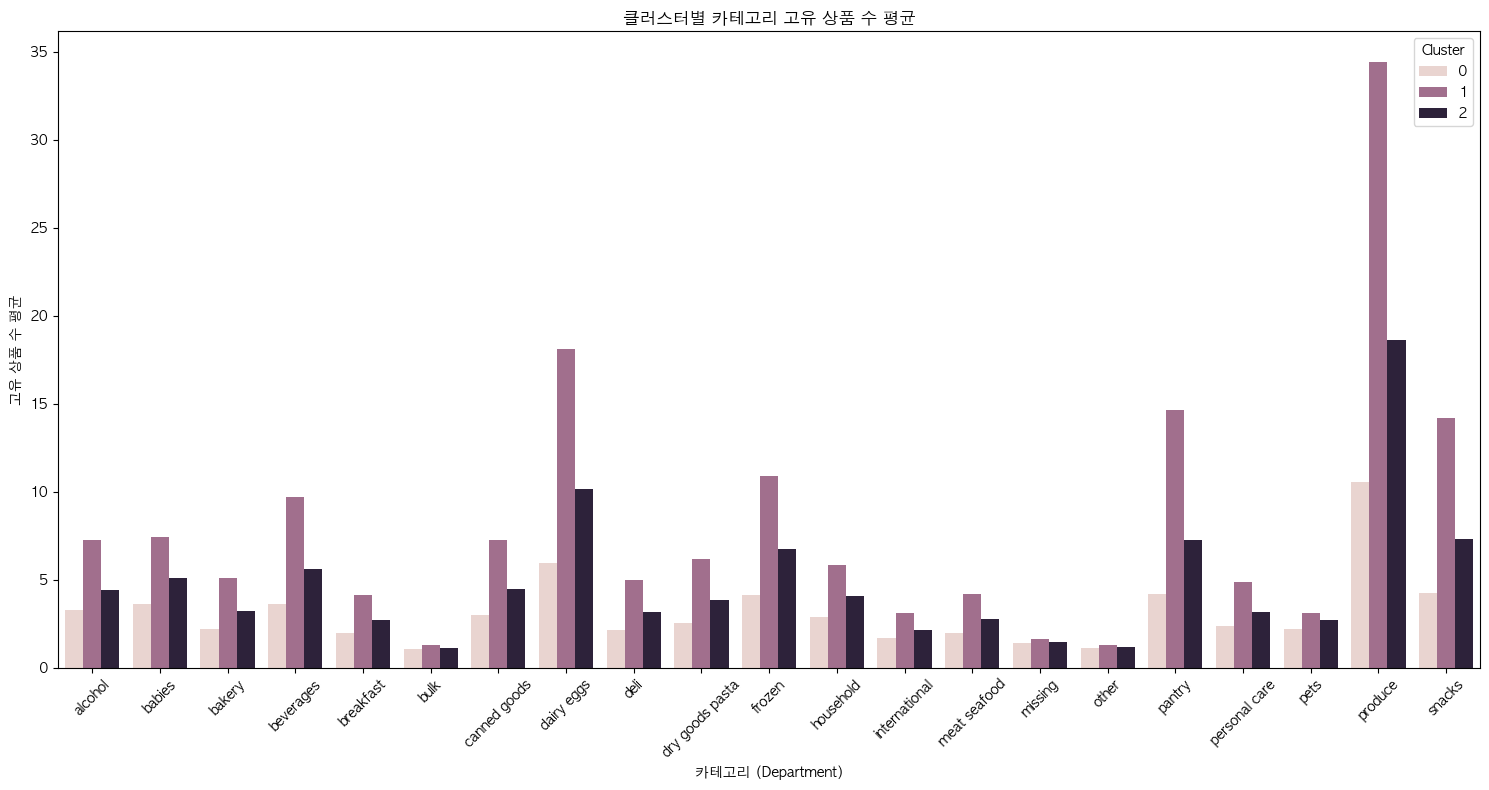

In [46]:
### 각 카테고리에서 몇 개의 고유 상품을 구매했는지 (department 기준)

# 고객-카테고리별 고유 상품 수 계산
user_category_unique = cluster_df.groupby(['cluster', 'user_id', 'department'])['product_id'].nunique().reset_index()
user_category_unique.columns = ['cluster', 'user_id', 'department', 'unique_product_count']

# 클러스터별, 카테고리별 고유 상품 수 평균 계산
category_unique_avg = user_category_unique.groupby(['cluster', 'department'])['unique_product_count'].mean().reset_index()

# 시각화 (클러스터별로 카테고리 고유 상품 수 평균 비교)
plt.figure(figsize=(15,8))
sns.barplot(data=category_unique_avg, x='department', y='unique_product_count', hue='cluster')
plt.xticks(rotation=45)
plt.title('클러스터별 카테고리 고유 상품 수 평균')
plt.xlabel('카테고리 (Department)')
plt.ylabel('고유 상품 수 평균')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


클러스터 1 (충성 고객): produce에서는 다양한 상품을 추천해도 될 듯 !

Produce (신선 과일/채소) 카테고리에서 고유 상품 수가 압도적으로 많음

그 다음으로 Dairy Eggs, Pantry, Snacks 순으로 다양하게 구매하는 경향

즉, 신선식품 위주로 다양한 상품을 시도하면서도, 가공식품, 간식 등 다른 카테고리도 폭넓게 구매함 → 다양한 식생활과 신뢰가 느껴짐

클러스터 2 (일반 고객):

Produce가 가장 많고 그 다음 Dairy Eggs로 비슷한 패턴이나, 충성 고객에 비해 고유 상품 수가 적음

다양성은 좀 적지만 기본적으로 신선식품 중심 소비

클러스터 0 (이탈 가능 고객 / 신규 고객):

전반적으로 고유 상품 수가 낮음

그나마 Produce가 비교적 높음 → 신선식품 위주로 적게 구매하거나 경험 중일 가능성

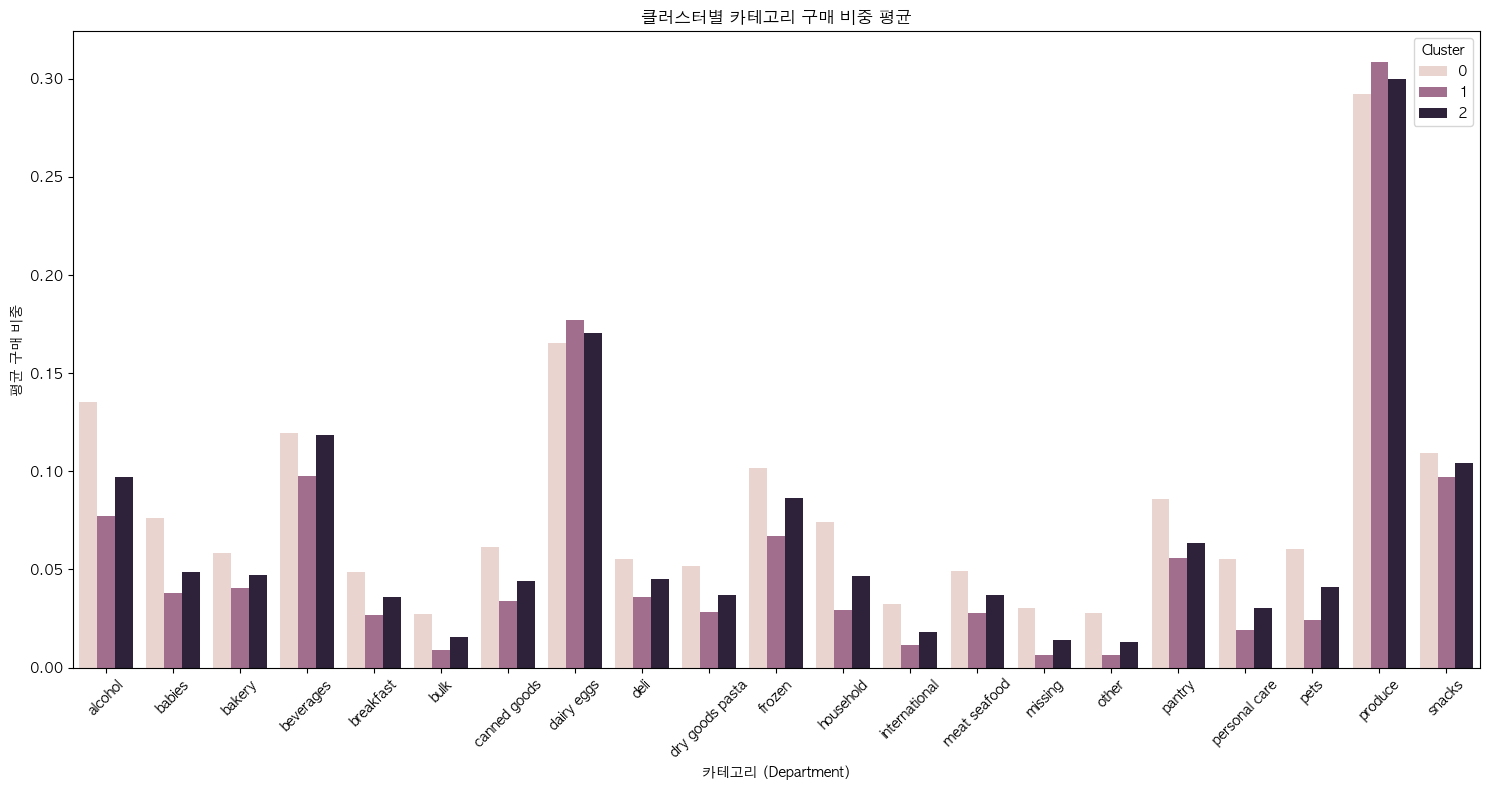

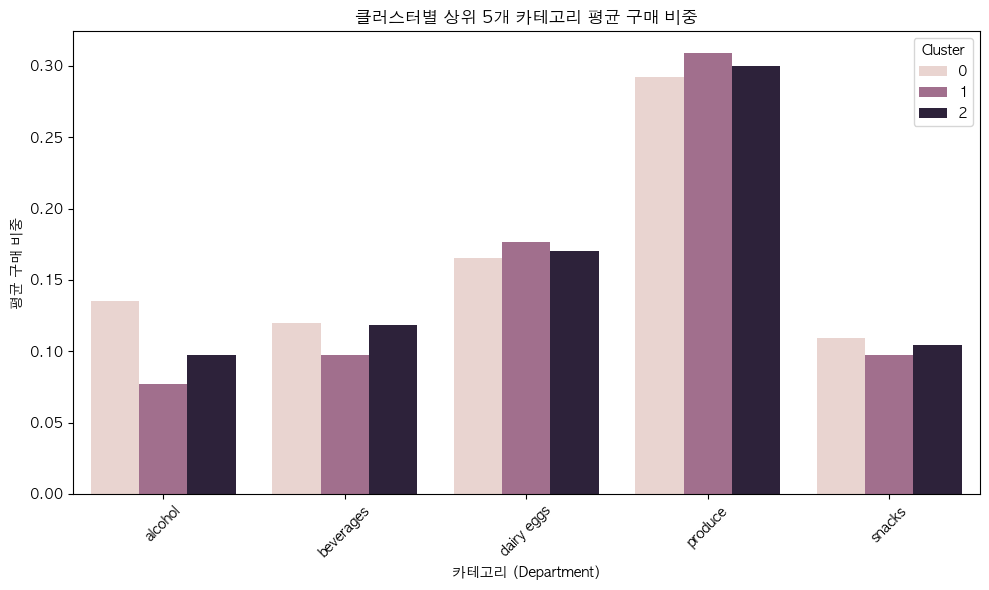

In [208]:
## 카테고리별 구매 비중 (클러스터별)

# 고객-카테고리별 구매 횟수 계산
user_category_count = cluster_df.groupby(['cluster', 'user_id', 'department']).size().reset_index(name='purchase_count')

# 고객별 전체 구매 횟수 계산
user_total_count = cluster_df.groupby(['cluster', 'user_id']).size().reset_index(name='total_purchase_count')

# 두 데이터 병합
user_category_ratio = pd.merge(user_category_count, user_total_count, on=['cluster', 'user_id'])

# 카테고리별 구매 비중 계산
user_category_ratio['purchase_ratio'] = user_category_ratio['purchase_count'] / user_category_ratio['total_purchase_count']

# 클러스터별, 카테고리별 평균 구매 비중 계산
category_ratio_avg = user_category_ratio.groupby(['cluster', 'department'])['purchase_ratio'].mean().reset_index()

# 시각화
plt.figure(figsize=(15,8))
sns.barplot(data=category_ratio_avg, x='department', y='purchase_ratio', hue='cluster')
plt.xticks(rotation=45)
plt.title('클러스터별 카테고리 구매 비중 평균')
plt.xlabel('카테고리 (Department)')
plt.ylabel('평균 구매 비중')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



# 1. 전체 평균 구매 비중이 높은 상위 5개 카테고리 추출
top5_departments = (
    category_ratio_avg
    .groupby('department')['purchase_ratio']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 2. 이 상위 5개만 필터링
top5_data = category_ratio_avg[category_ratio_avg['department'].isin(top5_departments)]

# 3. 시각화
plt.figure(figsize=(10,6))
sns.barplot(data=top5_data, x='department', y='purchase_ratio', hue='cluster')
plt.xticks(rotation=45)
plt.title('클러스터별 상위 5개 카테고리 평균 구매 비중')
plt.xlabel('카테고리 (Department)')
plt.ylabel('평균 구매 비중')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



| 클러스터         | 1순위            | 2순위                 | 3순위          | 4순위             | 5순위 |
| ------------ | -------------- | ------------------- | ------------ | --------------- | --- |
| 0 (이탈 가능/신규) | Produce (신선식품) | Dairy Eggs (유제품/계란) | Alcohol (주류) | Beverage (음료)   | -   |
| 1 (충성 고객)    | Produce (신선식품) | Dairy Eggs          | Snacks (간식)  | Beverage        | -   |
| 2 (일반 고객)    | Produce (신선식품) | Dairy Eggs          | Beverage     | Snacks, Alcohol | -   |




| 추천 전략 방향                                            |
| --------------------------------------------------- |
| 1) 모든 클러스터에 Produce, Dairy Eggs는 필수 포함 (기본 추천)      |
| 2) 클러스터별 3순위 이후 카테고리 중심으로 차별화 추천 (department 기준)    |
| 3) aisle 단위로 들어가서 클러스터별 특성에 맞는 세부 상품군 추천 (개인화 정밀도↑) |


In [55]:
##### 전체 요일-시간대-카테고리별 인기상품 Top N
#### top 카테고리 베스트


import pandas as pd

# 1) prior_df 복사 (원본 보호)
df = prior_df.copy()

# 2) 요일, 시간대, 카테고리, 상품별 구매 횟수 집계
grouped = (
    df.groupby(['order_dow', 'order_hour_of_day', 'department', 'product_name'])
      .size()
      .reset_index(name='purchase_count')
)

# 3) 요일, 시간대, 카테고리별 인기상품 Top N 추출 함수
def get_top_n_products(df, n=5):
    top_products = (
        df.sort_values(['order_dow', 'order_hour_of_day', 'department', 'purchase_count'], 
                       ascending=[True, True, True, False])
          .groupby(['order_dow', 'order_hour_of_day', 'department'])
          .head(n)
    )
    return top_products

top_n_products = get_top_n_products(grouped, n=5)

# 4) 결과 확인
print(top_n_products.head(15))

# 5) 필요하면 csv로 저장도 가능
# top_n_products.to_csv('top_n_products_by_time_category.csv', index=False)


     order_dow  order_hour_of_day department  \
29           0                  0    alcohol   
3            0                  0    alcohol   
20           0                  0    alcohol   
34           0                  0    alcohol   
1            0                  0    alcohol   
155          0                  0     babies   
95           0                  0     babies   
228          0                  0     babies   
114          0                  0     babies   
54           0                  0     babies   
252          0                  0     bakery   
385          0                  0     bakery   
282          0                  0     bakery   
356          0                  0     bakery   
504          0                  0     bakery   

                                       product_name  purchase_count  
29                                  Sauvignon Blanc               5  
3                                              Beer               4  
20                   

아까 위해서 말했던 top 카테고리 베스트를
클러스터별로 특정 요일/시간/카테고리 조합만 필터링해서 추천 상품 리스트 뽑으면 될 것 같음 !



| 클러스터      | 시간대         | 추천 내용                                                 |
| --------- | ----------- | ----------------------------------------------------- |
| 0 (이탈/신규) | 일요일 14\~15시 | 인기상품 + 해당 시간대 인기 상품 (Produce, Dairy Eggs 위주)          |
|           | 그 외 시간대     | 인기상품 위주                                               |
| 1 (충성 고객) | 월요일 9\~10시  | 재구매율 높은 상품 + 연관 상품 + top 카테고리 베스트 (Snacks, Beverage)    |
|           | 그 외 시간대     | 인기상품 위주                                             |
| 2 (일반 고객) | 일요일 13\~15시 | 재구매율 높은 상품 + top 카테고리별 베스트 상품 (Produce, Dairy Eggs 등) |
|           | 그 외 시간대     | 인기상품 위주                                               |


cluster
0     9.476582
1    10.317722
2    10.105922
Name: product_id, dtype: float64


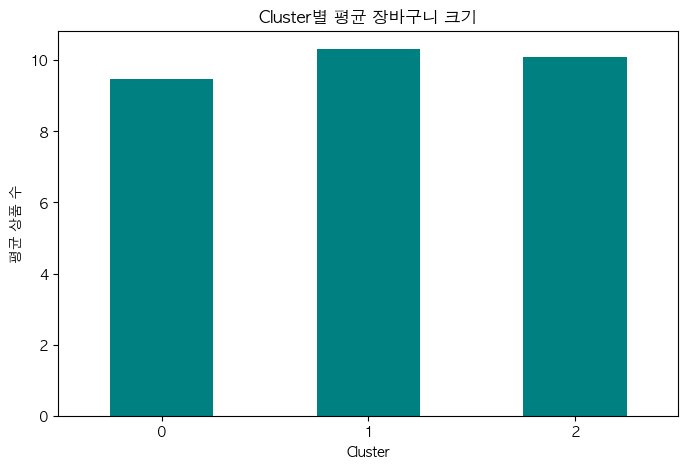

In [94]:
# 5. 군집별 장바구니 크기 (한 주문별 상품 개수 평균)

basket_size = cluster_df.groupby(['cluster', 'order_id'])['product_id'].count().reset_index()
basket_size_mean = basket_size.groupby('cluster')['product_id'].mean()
print(basket_size_mean)

# 5. 군집별 평균 장바구니 크기 막대그래프
plt.figure(figsize=(8,5))
basket_size_mean.plot(kind='bar', color='teal')
plt.title('Cluster별 평균 장바구니 크기')
plt.xlabel('Cluster')
plt.ylabel('평균 상품 수')
plt.xticks(rotation=0)
plt.show()

장바구니 크기:
군집 간의 차이가 명확하지 않아서 빼는게 나을 것 같음 !





## 행동 기반 군집

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


cluster_df = prior_df.copy()


# 1) 요일별 주문 비중
user_dow = cluster_df.groupby(['user_id', 'order_dow']).size().unstack(fill_value=0)
user_dow = user_dow.div(user_dow.sum(axis=1), axis=0)  # 비중 계산

# 2) 시간대별 주문 비중
user_hour = cluster_df.groupby(['user_id', 'order_hour_of_day']).size().unstack(fill_value=0)
user_hour = user_hour.div(user_hour.sum(axis=1), axis=0)

# 3) 카테고리별 주문 비중 (department 기준)
user_cat = cluster_df.groupby(['user_id', 'department']).size().unstack(fill_value=0)
user_cat = user_cat.div(user_cat.sum(axis=1), axis=0)

# 4) 장바구니 크기 (평균 상품 수)
cart_size = cluster_df.groupby('user_id')['order_id'].nunique()
avg_cart = cluster_df.groupby('user_id').agg({'add_to_cart_order':'max'}).rename(columns={'add_to_cart_order':'avg_cart_size'})

# 5) 모든 피처 병합
features = pd.concat([user_dow, user_hour, user_cat, avg_cart], axis=1).fillna(0)

# 컬럼명을 모두 문자열로 변환
features.columns = features.columns.astype(str)

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


# 7) 군집화 (예: 3개)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 8) 결과 저장
features['cluster_behavior'] = clusters

# 9) cluster_behavior별 분석 및 시각화 가능
# print(features['cluster_behavior'].value_counts())

In [244]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K=3으로 설정
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)

print(f"Silhouette Score (k=3): {score:.4f}")


,0,1,2,3,4,5,6,0,1,2,...,meat seafood,missing,other,pantry,personal care,pets,produce,snacks,avg_cart_size,cluster_behavior
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.288136,0.152542,0.186441,0.372881,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.016949,0.000000,0.0,0.084746,0.372881,9,0
2,0.000000,0.328205,0.446154,0.148718,0.046154,0.030769,0.000000,0.0,0.0,0.0,...,0.005128,0.000000,0.000000,0.056410,0.005128,0.0,0.184615,0.215385,26,0
3,0.522727,0.181818,0.056818,0.238636,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.045455,0.000000,0.0,0.431818,0.102273,11,1
4,0.000000,0.000000,0.000000,0.000000,0.500000,0.277778,0.222222,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.111111,0.055556,7,0
5,0.243243,0.324324,0.000000,0.432432,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.054054,0.000000,0.0,0.513514,0.027027,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,0.000000,0.000000,0.250000,0.000000,0.531250,0.218750,0.000000,0.0,0.0,0.0,...,0.031250,0.031250,0.000000,0.000000,0.000000,0.0,0.218750,0.000000,17,1
206206,0.238596,0.189474,0.115789,0.157895,0.168421,0.035088,0.094737,0.0,0.0,0.0,...,0.007018,0.000000,0.003509,0.049123,0.035088,0.0,0.119298,0.147368,24,1
206207,0.125561,0.192825,0.161435,0.183857,0.026906,0.134529,0.174888,0.0,0.0,0.0,...,0.026906,0.000000,0.000000,0.067265,0.000000,0.0,0.224215,0.103139,25,1


In [246]:
import pandas as pd

# 예: 기존 데이터 (컬럼명 없거나 이상한 상태)
# features 라는 DataFrame이라고 가정

# 1) 컬럼명 리스트 직접 준비 (예시)
weekday_cols = ['weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']
hour_cols = [f'hour_{i}' for i in range(24)]
category_cols = ['alcohol', 'babies', 'bakery', 'beverages', 'breakfast', 'bulk', 'canned goods',
                 'dairy eggs', 'deli', 'dry goods pasta', 'frozen', 'household', 'international',
                 'meat seafood', 'missing', 'other', 'pantry', 'personal care', 'pets', 'produce', 'snacks']

other_cols = ['avg_cart_size', 'cluster_behavior']

# 2) 모든 컬럼명을 순서대로 합치기 (features.columns 개수와 맞게)
new_columns = weekday_cols + hour_cols + category_cols + other_cols

# 3) 컬럼명 재할당
features.columns = new_columns

# 4) 확인
# print(features.columns)
# features


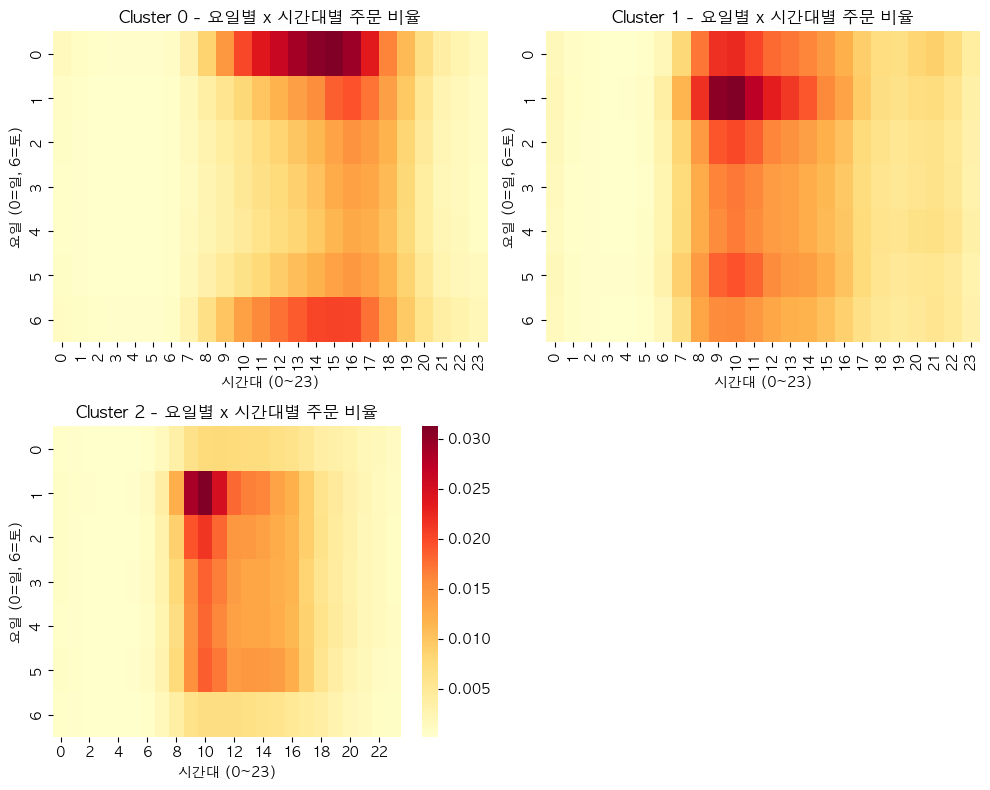

In [248]:

import matplotlib.pyplot as plt
import seaborn as sns




| 클러스터 | 주요 주문 시간대    | 주요 요일             | 특이사항                   | 제안 그룹 이름       |
| ---- | ------------ | ----------------- | ---------------------- | -------------- |
| 0번   | 오후 1시 \~ 5시  | **주말 중심**, 특히 일요일 | 평일보다 주말에만 몰려 있음        | **주말 집중형 고객**  |
| 1번   | 오전 9시 \~ 10시 | **월요일**           | 주초에 쇼핑 시작, 일요일에도 일부 있음 | **정기 쇼핑형 고객**  |
| 2번   | 오전 9시 \~ 10시 | **월요일만**          | 주말엔 아예 없음, 평일 집중형      | **직장인 루틴형 고객** |

공통적인 특징 : 한 주의 시작에 정기적으로 필요한 물품을 미리 사두는 습관



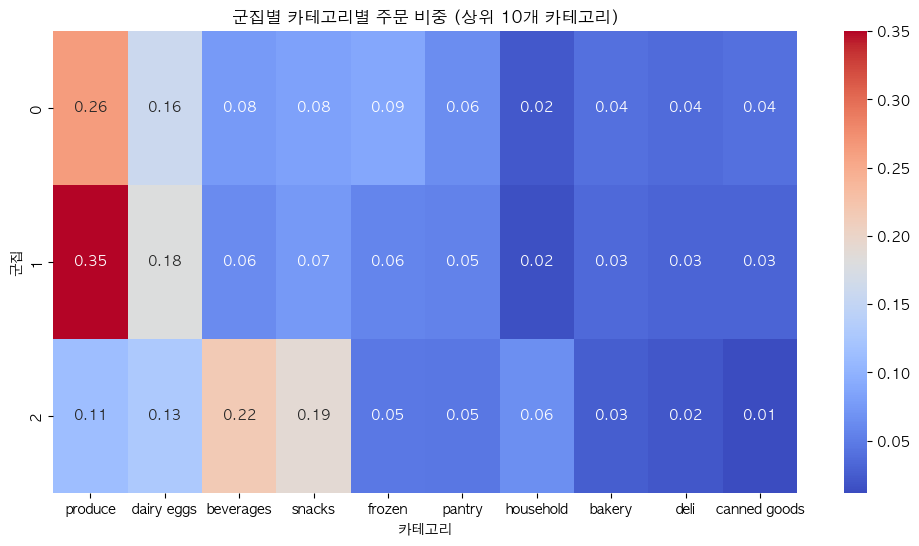

In [171]:
# 원본 데이터 복사
prior_df_copy = prior_df.copy()

# user_id와 cluster_behavior 컬럼이 있는 features에서 클러스터 정보 가져오기
user_clusters = features[['cluster_behavior']].reset_index()

# 복사한 데이터에 클러스터 정보 병합
prior_df_copy = prior_df_copy.merge(user_clusters, on='user_id', how='left')

# 군집별, 카테고리별 주문 수 집계
category_counts = prior_df_copy.groupby(['cluster_behavior', 'department']).size().unstack(fill_value=0)

# 군집별 총 주문 수로 나누어 비중 계산
category_ratio = category_counts.div(category_counts.sum(axis=1), axis=0)

# 상위 몇 개 카테고리만 보고 싶으면 예를 들어 상위 10개
top_categories = category_ratio.sum().sort_values(ascending=False).head(10).index
category_ratio_top = category_ratio[top_categories]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(category_ratio_top, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("군집별 카테고리별 주문 비중 (상위 10개 카테고리)")
plt.xlabel("카테고리")
plt.ylabel("군집")
plt.show()


| 클러스터 | 주요 주문 시간대    | 주요 요일             | 특이사항                               | 제안 그룹 이름       | 마케팅 전략 예시                                                                           |
| ---- | ------------ | ----------------- | ---------------------------------- | -------------- | ----------------------------------------------------------------------------------- |
| 0번   | 오후 1시 \~ 5시  | **주말 중심**, 특히 일요일 | 평일보다 주말 주문 집중, 주말 쇼핑에 주력           | **주말 집중형 고객**  | - 주말 특별 프로모션, 주말 인기상품 추천<br>- 신선식품, 유제품, 음료 등 주말 인기 카테고리 집중 추천<br>- 주말 타임딜 이벤트 진행   |
| 1번   | 오전 9시 \~ 10시 | **월요일**           | 주초 쇼핑을 통해 주간 소비 계획, 일요일에도 일부 구매 있음 | **정기 쇼핑형 고객**  | - 월요일 아침 맞춤 할인 쿠폰 제공<br>- 재구매율 높은 상품과 연관상품 추천<br>- 장바구니 크기 고려한 묶음 할인 제안             |
| 2번   | 오전 9시 \~ 10시 | **월요일만**          | 평일 집중 구매, 주말은 거의 주문 없음             | **직장인 루틴형 고객** | - 월요일 출근 전 맞춤 알림 및 추천상품 발송<br>- 간편하고 빠른 구매 유도 (베스트셀러, 스낵, 음료 등)<br>- 정기구독 서비스 제안 가능 |


   cluster  평균 장바구니 크기  중앙값     주문 수
0        0   10.855242  9.0  1208001
1        1   10.627676  9.0  1518399
2        2    6.518861  5.0   488474


/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2342/3270428919.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_behavior', y='cart_size', data=cluster_cart_stats, palette='Set2')


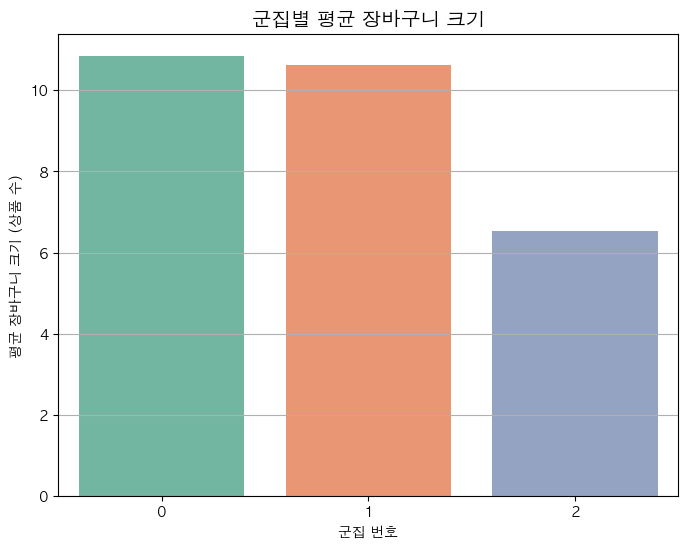

In [162]:
# prior_df_copy에 cluster_behavior가 붙어 있어야 해!

# 1. 주문별 장바구니 크기 계산 (order_id 기준으로 몇 개의 상품을 담았는지)
order_size = prior_df_copy.groupby('order_id').size().reset_index(name='cart_size')

# 2. 각 주문에 대응되는 user_id와 cluster_behavior 정보 가져오기 (order_id 기준으로 병합)
order_cluster = prior_df_copy[['order_id', 'user_id', 'cluster_behavior']].drop_duplicates()
order_size = order_size.merge(order_cluster, on='order_id', how='left')

# 3. 군집별 평균 장바구니 크기 계산
cluster_cart_stats = order_size.groupby('cluster_behavior')['cart_size'].agg(['mean', 'median', 'count']).reset_index()
cluster_cart_stats.columns = ['cluster', '평균 장바구니 크기', '중앙값', '주문 수']
print(cluster_cart_stats)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 군집별 평균 장바구니 크기 계산 (앞에서 만든 order_size 사용)
cluster_cart_stats = order_size.groupby('cluster_behavior')['cart_size'].mean().reset_index()

# 2. 시각화
plt.figure(figsize=(8,6))
sns.barplot(x='cluster_behavior', y='cart_size', data=cluster_cart_stats, palette='Set2')
plt.title('군집별 평균 장바구니 크기', fontsize=14)
plt.xlabel('군집 번호')
plt.ylabel('평균 장바구니 크기 (상품 수)')
plt.grid(axis='y')
plt.show()



| 군집 | 평균 장바구니 크기 | 중앙값 | 주문 수      | 해석 키워드                           |
| -- | ---------- | --- | --------- | -------------------------------- |
| 0  | 10.86      | 9   | 1,208,001 | **주말 쇼핑족**, 가족 단위, 대량 구매         |
| 1  | 10.63      | 9   | 1,518,399 | **정기적 루틴형**, 주초 장보기, 고정 습관       |
| 2  | 6.52       | 5   | 488,474   | **소량 구매자**, 1인 가구 또는 직장인, 불규칙 구매 |


# 부록: 추가 EDA 및 모델링 시도

## 추가 EDA

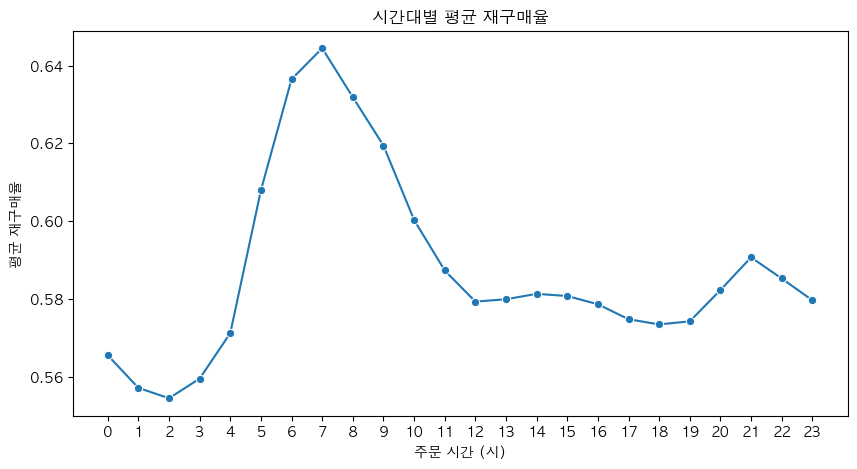

In [164]:
df = prior_df.copy()
hour_reorder = df.groupby('order_hour_of_day')['reordered'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hour_reorder, x='order_hour_of_day', y='reordered', marker='o')
plt.title('시간대별 평균 재구매율')
plt.xlabel('주문 시간 (시)')
plt.ylabel('평균 재구매율')
plt.xticks(range(0,24))
plt.show()


# 아침 6~8시에 가장 재구매율이 높다   ->   시간대별 재구매 패턴을 활용한 푸시 알림 또는 마케팅면에서 활용 가능.

/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2838/2196312820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_dow_reorder, x='order_dow', y='reordered', palette='pastel')


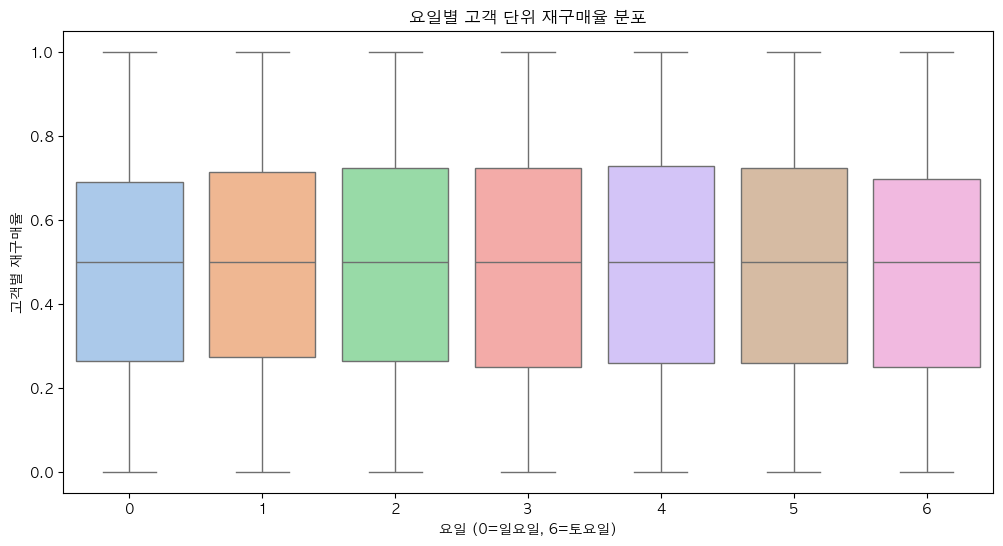

In [166]:
user_dow_reorder = df.groupby(['user_id', 'order_dow'])['reordered'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.boxplot(data=user_dow_reorder, x='order_dow', y='reordered', palette='pastel')
plt.title('요일별 고객 단위 재구매율 분포')
plt.xlabel('요일 (0=일요일, 6=토요일)')
plt.ylabel('고객별 재구매율')
plt.show()


재구매율은 특정 요일에 크게 영향을 받지 않음 !

-> 여기서 알 수 있는 점은 , 
재구매가 대부분 '필수적이고 일상적인(Daily) 상품'에서 발생한다

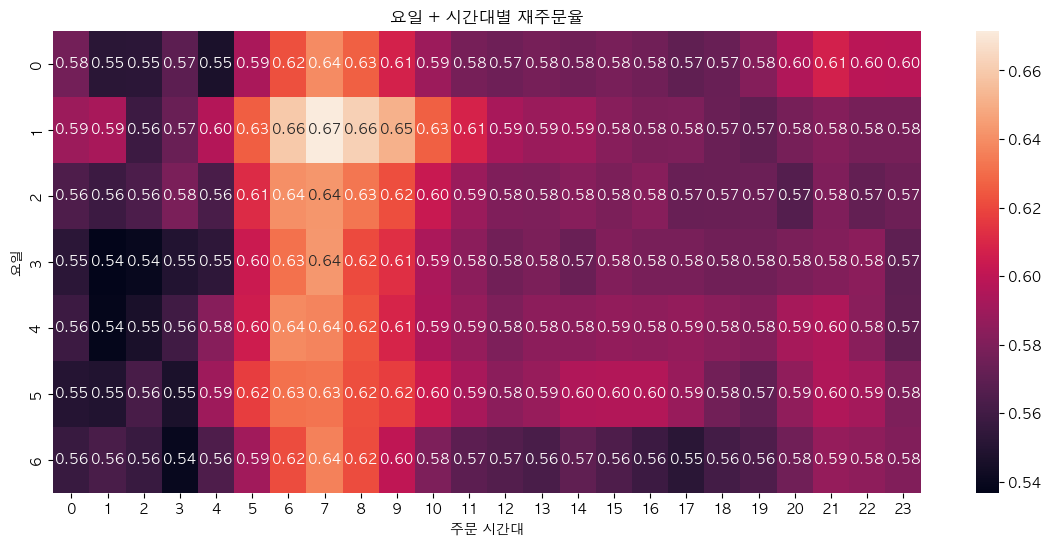

In [168]:
prior_df_pivot = prior_df.pivot_table(columns = 'order_hour_of_day', index = 'order_dow', values = 'reordered', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(prior_df_pivot, annot=True, fmt='.2f')
plt.title('요일 + 시간대별 재주문율')
plt.xlabel('주문 시간대')
plt.ylabel('요일')
plt.show()

# 오전 6시 ~ 8시가 대체적으로 재주문율이 높은 시간대 (특히 월요일) 
# 출근 / 하루의 시작 전 주문 루틴일 가능성 

In [ ]:
요일과 무관하게 오전 6~8시 재구매율이 높은 것으로 보아, 요거트, 우유 등 아침식사용 데일리 제품의 반복 구매가 많을 것으로 추정된다.

## 고객 개인 장바구니 분석

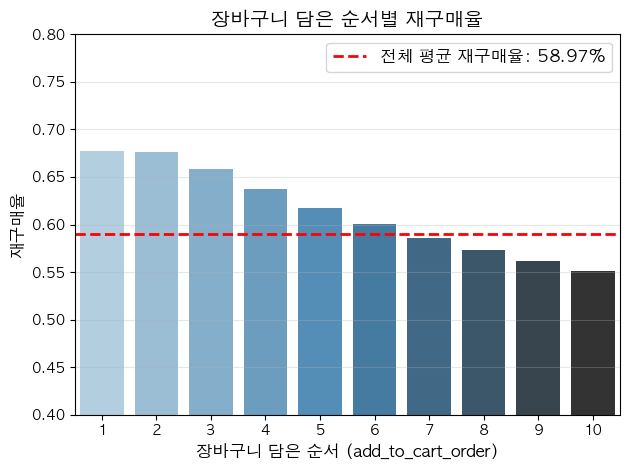

In [197]:
# 장바구니의 첫번째 상품과 재구매율의 연관성 확인 
reorder_rates_by_order = prior_df[prior_df['add_to_cart_order'] <= 10].groupby('add_to_cart_order')['reordered'].mean().reset_index()

# 전체 상품 재구매율
overall_reorder_rate = prior_df['reordered'].mean()
overall_reorder_rate
sns.barplot(
    data=reorder_rates_by_order,
    x='add_to_cart_order',
    y='reordered',
    hue='add_to_cart_order',
    palette='Blues_d',
    legend=False
)

# 전체 재구매율 수평선 + 범례 포함
plt.axhline(
    y=overall_reorder_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'전체 평균 재구매율: {overall_reorder_rate*100:.2f}%'
)

plt.legend(loc='upper right', fontsize=12)
plt.title('장바구니 담은 순서별 재구매율', fontsize=14)
plt.xlabel('장바구니 담은 순서 (add_to_cart_order)', fontsize=12)
plt.ylabel('재구매율', fontsize=12)
plt.ylim(0.4, 0.8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

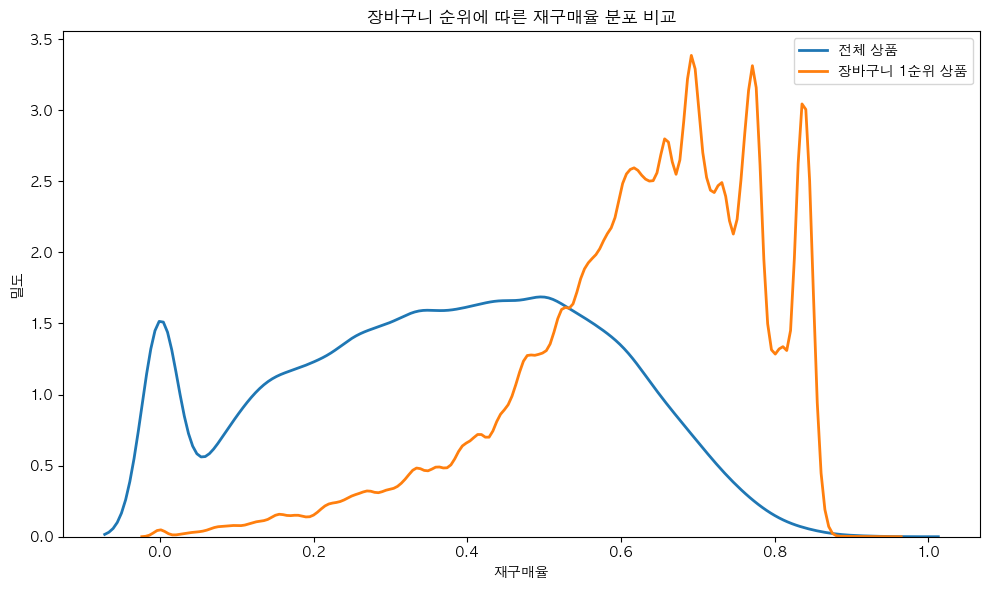

In [199]:
# 장바구니 첫번째 상품들의 재구매율
cart_order_1 = prior_df[prior_df['add_to_cart_order'] == 1]
cart_order_1


product_reorder = prior_df.groupby('product_name')['reordered'].mean().reset_index()
product_reorder.columns = ['product_name', 'reorder_ratio']

cart1_reorder = pd.merge(cart_order_1, product_reorder, on='product_name', how='left')

# 첫번째로 담긴 상품의 재구매율이 다른 상품들의 재구매율보다 유의미한 차이가 있는지 시각화

plt.figure(figsize=(10,6))
sns.kdeplot(data=product_reorder, x='reorder_ratio', label='전체 상품', linewidth=2)
sns.kdeplot(data=cart1_reorder, x='reorder_ratio', label='장바구니 1순위 상품', linewidth=2)

plt.title('장바구니 순위에 따른 재구매율 분포 비교')
plt.xlabel('재구매율')
plt.ylabel('밀도')
plt.legend()
plt.tight_layout()
plt.show()


- 재구매율이 대략 0.5~0.8 사이에서 높은 밀도(0.7 이상에 피크 밀집) => 재구매율이 높은 제품들이 많다.
- 신뢰 높은 제품을 가장 먼저 장바구니에 담는 경향이 있다. 

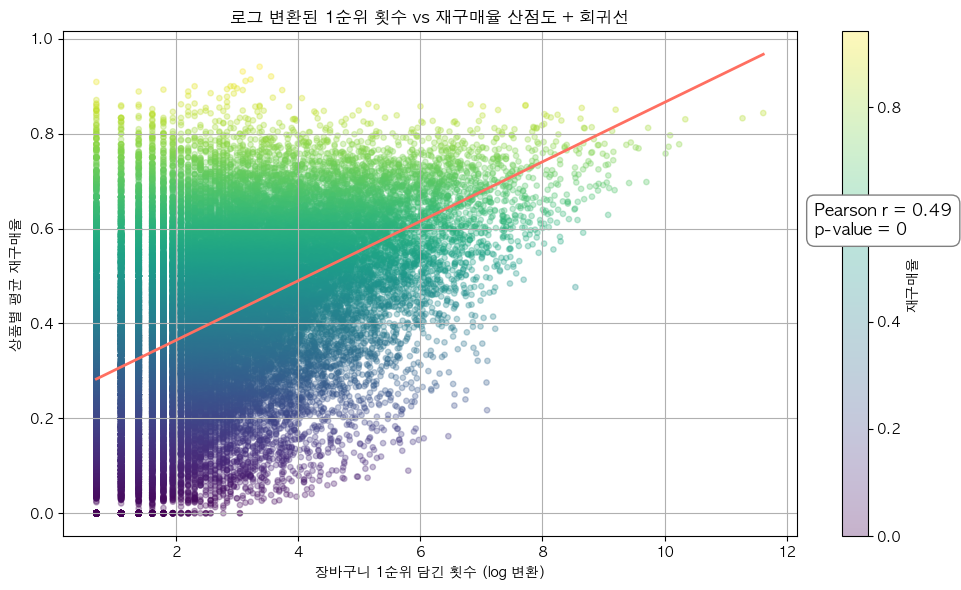

In [207]:
from scipy import stats


# add_to_cart_order == 1인 데이터 추출 (장바구니에서 제일 먼저 담긴 상품)
first_order_df = prior_df[prior_df['add_to_cart_order'] == 1]

# 상품별 첫 담김 횟수
first_order_count = first_order_df.groupby('product_id').size().reset_index(name='first_order_count')

# 상품별 재구매율 계산
reorder_ratio = prior_df.groupby('product_id')['reordered'].mean().reset_index(name='reorder_ratio')

# 합치기
product_summary = pd.merge(first_order_count, reorder_ratio, on='product_id')

# 로그 변환 (log(1+x)로 0 처리)
product_summary['first_order_count_log'] = np.log1p(product_summary['first_order_count'])



# 상관계수 계산
corr_log, p_value_log = stats.pearsonr(
    product_summary['first_order_count_log'],
    product_summary['reorder_ratio']
)

# 시각화
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    product_summary['first_order_count_log'],
    product_summary['reorder_ratio'],
    alpha=0.3,
    s=15,
    c=product_summary['reorder_ratio'],
    cmap='viridis'
)

# 회귀선 그리기 (코랄 색상)
sns.regplot(
    x='first_order_count_log',
    y='reorder_ratio',
    data=product_summary, ####
    scatter=False,
    line_kws={'color': '#FF6F61', 'linewidth': 2},
    ci=None
)

# 라벨
plt.xlabel('장바구니 1순위 담긴 횟수 (log 변환)')
plt.ylabel('상품별 평균 재구매율')
plt.title('로그 변환된 1순위 횟수 vs 재구매율 산점도 + 회귀선')
plt.colorbar(scatter, label='재구매율')
plt.grid(True)

# 오른쪽 바깥쪽에 상관계수 표시 (axes fraction 기준)
plt.gcf().text(
    0.82, 0.6,
    f'Pearson r = {corr_log:.2f}\np-value = {p_value_log:.2g}',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5')
)

plt.tight_layout()
plt.show()


장바구니의 1순위 상품과 재구매 비율은 어느정도 연관이 있다.
- 상관계수 = 0.54

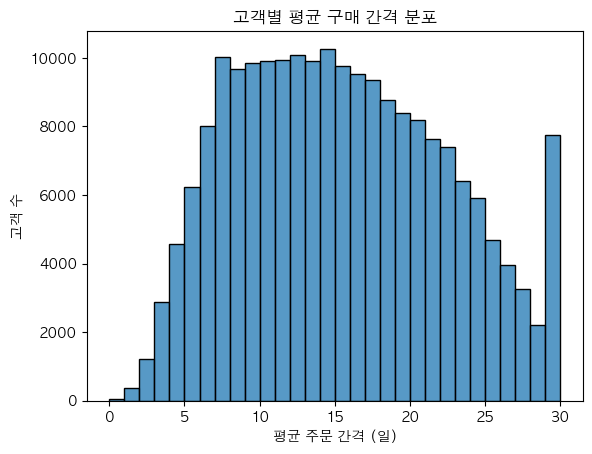

In [202]:

# 고객별 평균 주문 간격 구하기
avg_days_per_user = orders.groupby('user_id')['days_since_prior_order'].mean().reset_index()
avg_days_per_user.columns = ['user_id', 'avg_days_between_orders']


sns.histplot(avg_days_per_user['avg_days_between_orders'], bins=30)
plt.title('고객별 평균 구매 간격 분포')
plt.xlabel('평균 주문 간격 (일)')
plt.ylabel('고객 수')
plt.show()


- 한 1~2주 간격으로 재구매를 많이 함.
- 이는 많은 고객들이 주 1회 혹은 격주 간격으로 장을 본다는 것을 의미함.

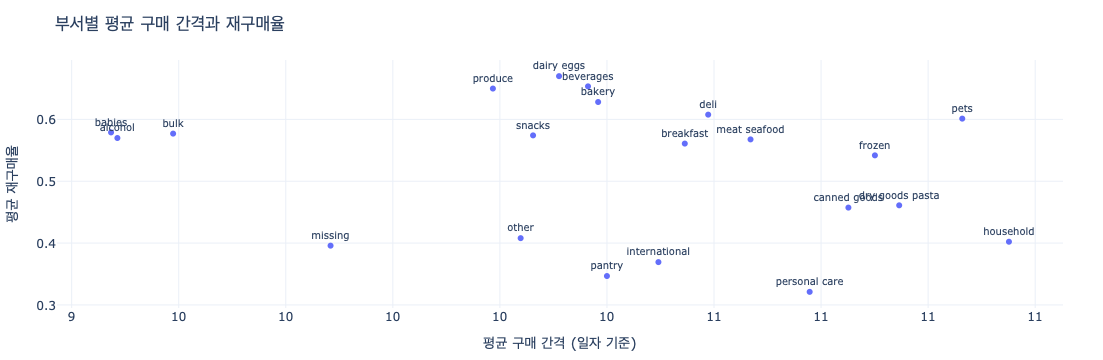

In [212]:
order_days_dept = prior_df[['order_id', 'department', 'days_since_prior_order']]

dept_avg_days = order_days_dept.groupby('department')['days_since_prior_order'].mean().sort_values()
dept_avg_days


dept_reorder_rate = prior_df.groupby('department')['reordered'].mean()

dept_summary = pd.concat([dept_reorder_rate, dept_avg_days], axis=1).reset_index()
dept_summary.columns = ['department', '평균 재구매율', '평균 구매 간격']


import plotly.express as px

fig = px.scatter(
    dept_summary, 
    x='평균 구매 간격', 
    y='평균 재구매율', 
    text='department',
    hover_data={'department': True, '평균 구매 간격': '.2f', '평균 재구매율': '.2f'}, 
    title='부서별 평균 구매 간격과 재구매율'
)

fig.update_traces(
    textposition='top center', 
    hovertemplate='평균 간격: %{x:.2f}<br>재구매율: %{y:.2f}<extra></extra>', 
    textfont=dict(size=10)
)

fig.update_layout(
    xaxis_title='평균 구매 간격 (일자 기준)', 
    yaxis_title='평균 재구매율', 
    xaxis_tickformat=',d',  # 정수로 표시
    template='plotly_white', 
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()


In [216]:
department_stats = prior_df.groupby('department').agg(
    reorder_rate = ('reordered', 'mean'),
    avg_reorder_interval = ('days_since_prior_order', 'mean')
).reset_index()

corr = department_stats['avg_reorder_interval'].corr(department_stats['reorder_rate'])
print(f"구매주기와 재구매율의 상관계수: {corr:.3f}")

구매주기와 재구매율의 상관계수: -0.241


구매 주기와 재구매율과는 크게 연관이 없음. (약한 상관관계)

그렇다면 구매주기가 짧은 만큼 재구매율도 높을까????

꼭 그렇지 않음 ! 


구매 주기가 짧은 카테고리 :
babies (아기 용품): 육아 필수품이라 빨리 소진돼서 자주 재구매할 가능성이 높고,

alcohol (주류): 소모가 빠르거나, 파티/모임 등으로 일정 주기로 구매하는 경우,

bulk (대용량 상품): 많이 사서 금방 줄지만 정기적으로 구매하는 고객들이 많을 수 있다.


## 인기상품 리스트 만들기

인기상품은 주문건수, 재구매율을 몇으로 잡아야 할까?

In [174]:
## (1) 상품별 재구매율 분포 

product_reorder_rate = prior_df.groupby('product_id').agg( total_orders = ('reordered', 'count'), total_reorders = ('reordered', 'sum'))

product_reorder_rate['reorder_rate'] = product_reorder_rate['total_reorders'] / product_reorder_rate['total_orders']

product_reorder_rate = product_reorder_rate.sort_values(by='reorder_rate', ascending=False)


product_reorder_rate = product_reorder_rate.merge(products_merged, on = 'product_id', how='left')

product_reorder_rate

,product_id,total_orders,total_reorders,reorder_rate,product_name,aisle_id,department_id,aisle,department
0,6433,68,64,0.941176,Raw Veggie Wrappers,13,20,prepared meals,deli
1,2075,87,81,0.931034,Serenity Ultimate Extrema Overnight Pads,126,11,feminine care,personal care
2,43553,13,12,0.923077,Orange Energy Shots,64,7,energy sports drinks,beverages
3,27740,101,93,0.920792,Chocolate Love Bar,45,19,candy chocolate,snacks
4,14609,35,32,0.914286,Soy Powder Infant Formula,92,18,baby food formula,babies
...,...,...,...,...,...,...,...,...,...
49672,38923,6,0,0.000000,Sd All Purpose Scouring Pad,114,17,cleaning products,household
49673,46234,6,0,0.000000,Tummy Ache Natural Relief Quick-Dissolving Tab...,6,2,other,other
49674,19864,20,0,0.000000,Volumizing Conditioner,22,11,hair care,personal care
49675,4327,7,0,0.000000,Organic Total Body Cleanse,6,2,other,other


In [176]:
### 상품별 주문건수 집계

product_quantiles = product_reorder_rate['total_orders'].quantile([0.9, 0.95,0.97,0.98, 0.99, 1.0])
print(product_quantiles)

# 9931개 이상 팔린 상품이 상위 1% 이내
# 2286개 이상 팔린 상품이 상위 5% 이내

0.90      1021.00
0.95      2286.00
0.97      3811.16
0.98      5477.88
0.99      9931.16
1.00    472565.00
Name: total_orders, dtype: float64


In [178]:
## 상품별 재구매율 집계

reorder_rate_90p = product_reorder_rate['reorder_rate'].quantile([0.9, 0.95, 0.97,0.98, 0.99, 1.0])
print(f"상위 10% 재구매율 기준값: \n{reorder_rate_90p}")

# 상위 1%는 0.77정도
# 상위 5%는 0.69정도

상위 10% 재구매율 기준값: 
0.90    0.634010
0.95    0.688889
0.97    0.719356
0.98    0.741935
0.99    0.772983
1.00    0.941176
Name: reorder_rate, dtype: float64


In [180]:
order_99_percentile = 9931 # 예: 주문수 상위 1% 컷
reorder_99_percentile = 0.77  # 재구매율 상위 1% 컷

# 인기 상품 필터링
popular_products = product_reorder_rate[
    (product_reorder_rate['total_orders'] >= order_99_percentile) &
    (product_reorder_rate['reorder_rate'] >= reorder_99_percentile)
]

# print(f"주문수 상위 10% 이상내 & 재구매율 상위 10% 이내인 인기 상품 개수: {len(popular_products)}")
print(f"주문수 상위 5% 이내 & 재구매율 상위 1% 이내인 인기 상품 개수: {len(popular_products)}")

# 상위 인기 상품 리스트 간단히 확인
print(popular_products[['product_name', 'total_orders', 'reorder_rate']].head(10))


주문수 상위 5% 이내 & 재구매율 상위 1% 이내인 인기 상품 개수: 43
                             product_name  total_orders  reorder_rate
51               Milk, Organic, Vitamin D         20198      0.854342
54               Organic Reduced Fat Milk         35663      0.850686
72                                 Banana        472565      0.843501
80                 Organic Lowfat 1% Milk         14869      0.839868
87   Organic Milk Reduced Fat, 2% Milkfat         12737      0.837481
107                Bag of Organic Bananas        379450      0.832555
109                 Organic Fat Free Milk         26591      0.831823
114                    Organic Whole Milk        137905      0.830354
120              0% Greek Strained Yogurt         13238      0.827769
152   Organic Whole Milk with DHA Omega-3         13528      0.820520


/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2838/1550303593.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2838/1550303593.py:7: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(
/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_2838/1550303593.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Aisle')

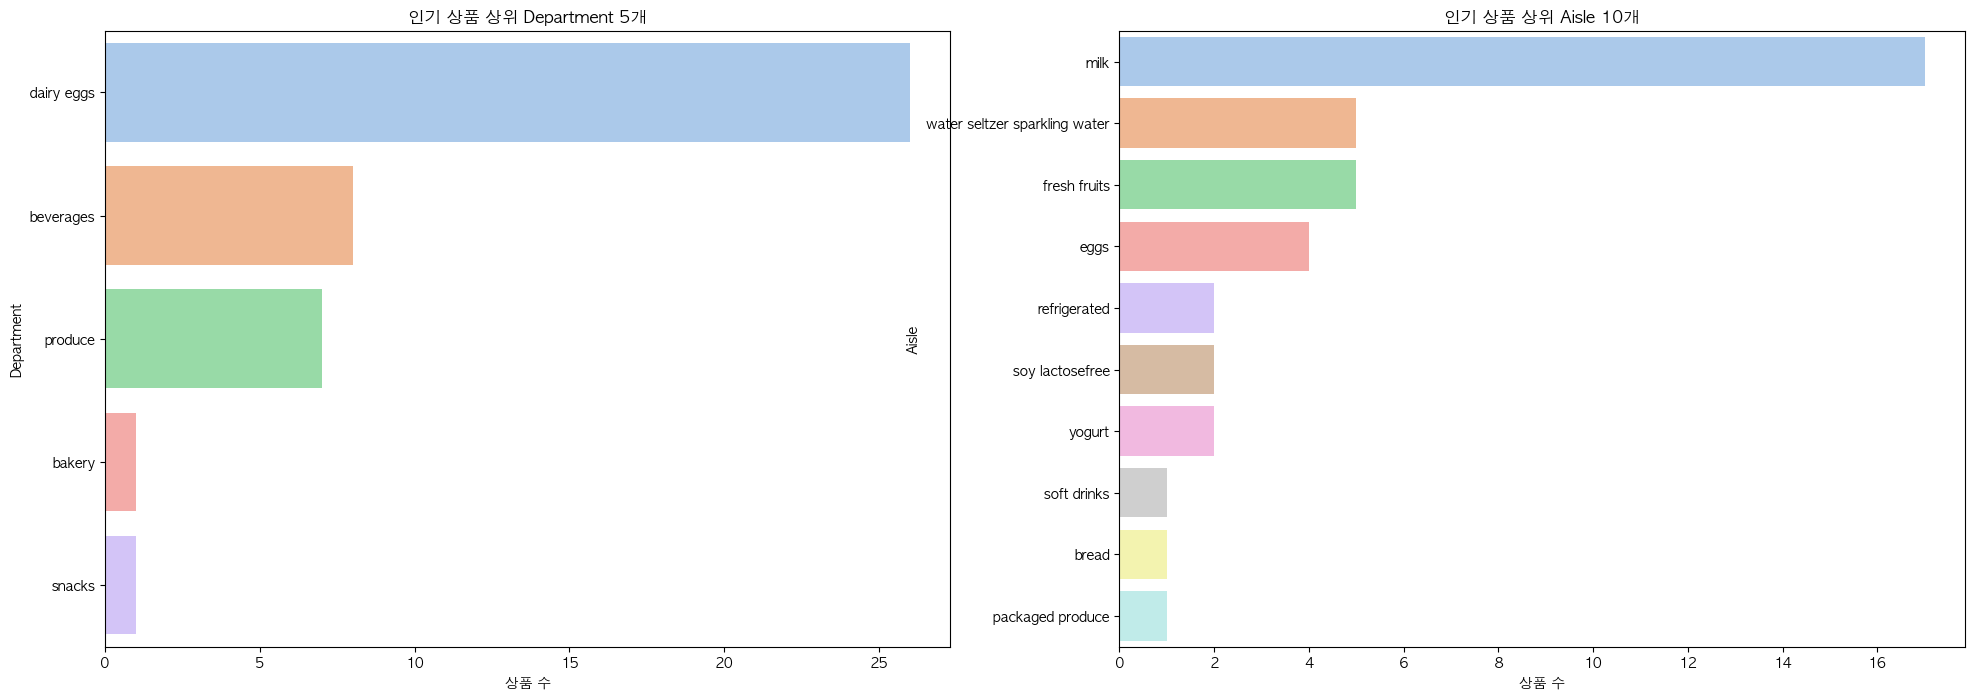

In [188]:
## 인기상품 분포 확인


fig, axes = plt.subplots(1, 2, figsize=(24, 8))  # 1행 3열

# 1) Department 분포
sns.barplot(
    y=dept_counts.index, 
    x=dept_counts.values, 
    palette=sns.color_palette('pastel'),
    ax=axes[0]
)
axes[0].set_title("인기 상품 상위 Department 5개")
axes[0].set_xlabel("상품 수")
axes[0].set_ylabel("Department")

# 2) 상위 Aisle 10개
sns.barplot(
    y=aisle_counts.head(10).index, 
    x=aisle_counts.head(10).values, 
    palette=sns.color_palette('pastel'),
    ax=axes[1]
)
axes[1].set_title("인기 상품 상위 Aisle 10개")
axes[1].set_xlabel("상품 수")
axes[1].set_ylabel("Aisle")


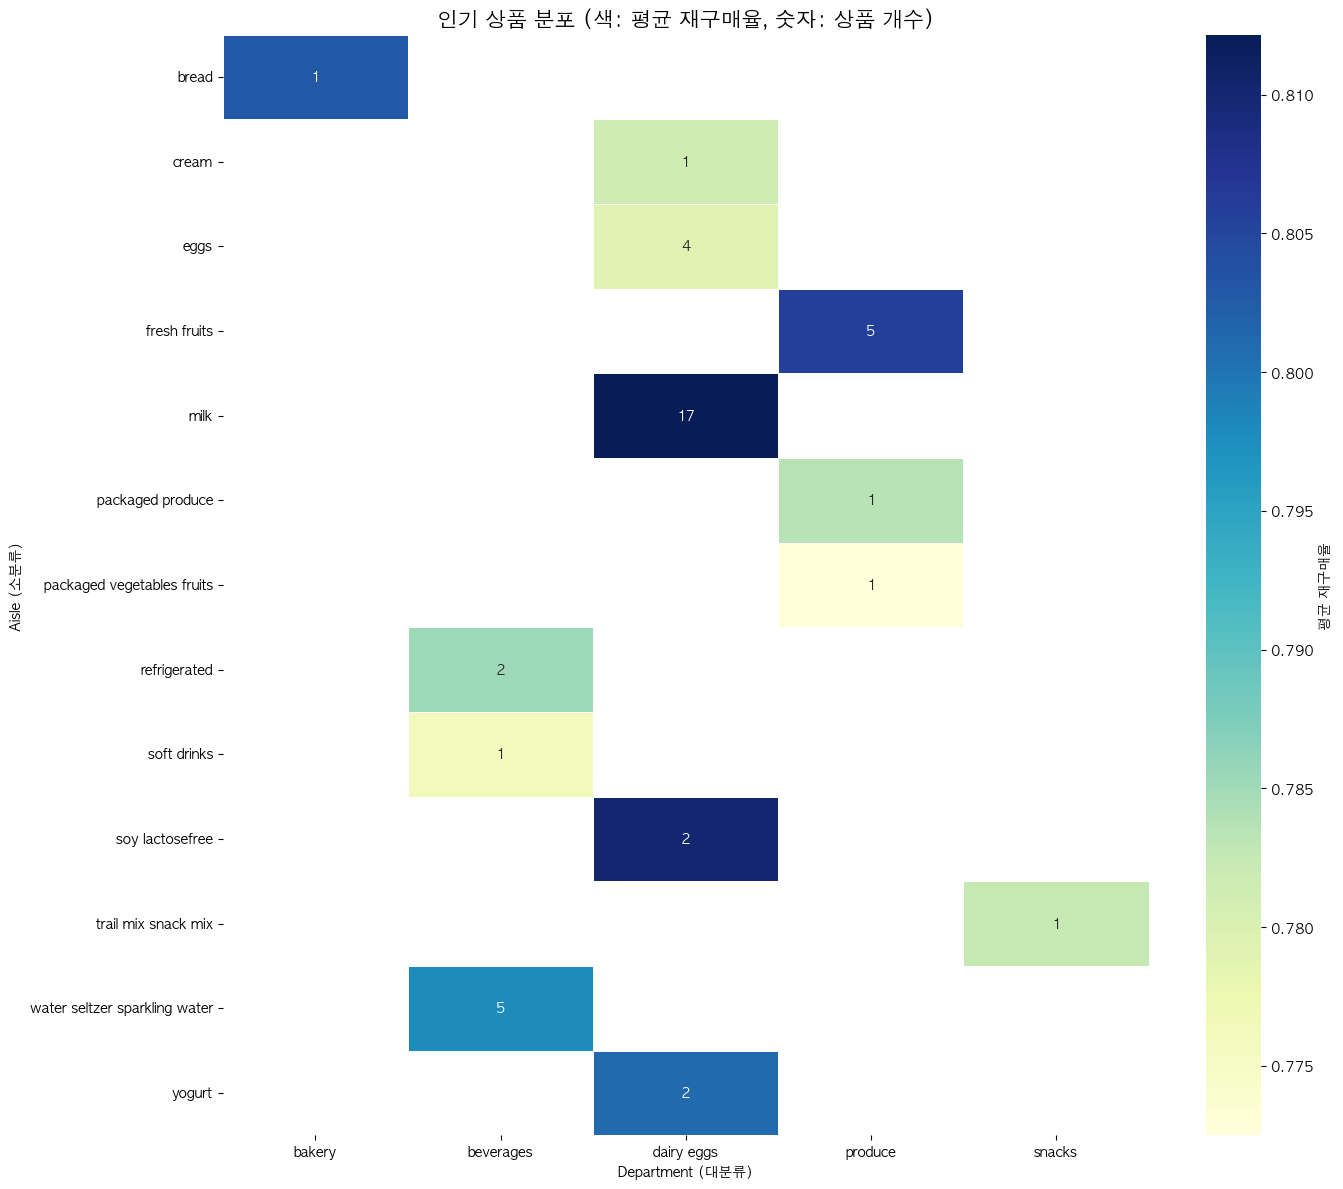

In [184]:
# 인기 상품 분포 히트맵


# 1. 카테고리별 인기 상품 수 + 평균 재구매율 계산
heatmap_data = (
    popular_products
    .groupby(['department', 'aisle'])
    .agg(
        product_count=('product_name', 'count'),
        mean_reorder_rate=('reorder_rate', 'mean')
    )
    .reset_index()
)

# 2. 피벗 테이블: 히트맵용
count_pivot = heatmap_data.pivot(index='aisle', columns='department', values='product_count')
reorder_pivot = heatmap_data.pivot(index='aisle', columns='department', values='mean_reorder_rate')



### 재구매율이 색깔, 인기상품수가 숫자
plt.figure(figsize=(14, 12))

# 히트맵 (색은 reorder rate)
sns.heatmap(reorder_pivot, 
            cmap='YlGnBu', 
            annot=count_pivot,        # 텍스트는 상품 수
            fmt='.0f', 
            linewidths=0.5, 
            cbar_kws={'label': '평균 재구매율'})

plt.title('인기 상품 분포 (색: 평균 재구매율, 숫자: 상품 개수)', fontsize=15)
plt.xlabel('Department (대분류)')
plt.ylabel('Aisle (소분류)')
plt.tight_layout()
plt.show()

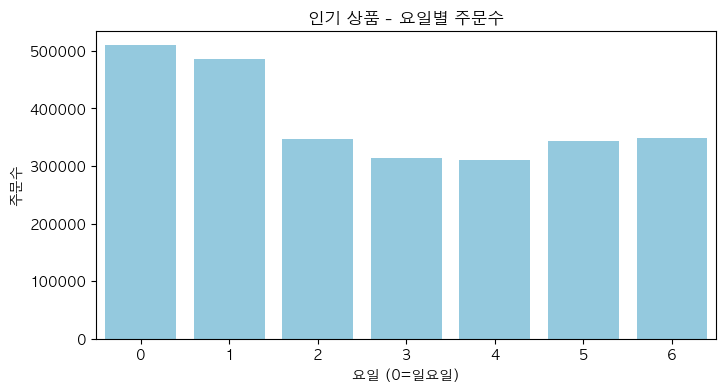

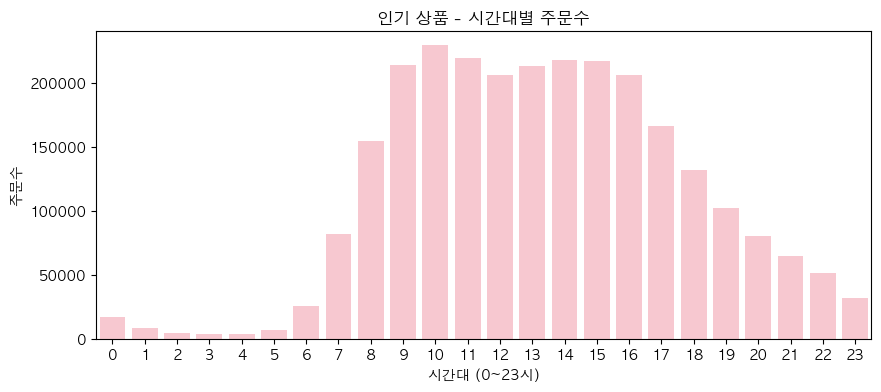

In [190]:
# 인기 상품 ID 목록 추출
popular_product_ids = popular_products['product_id'].unique()

# prior 기준으로 인기 상품 중 시간대/요일 분석
popular_orders = order_prior[order_prior['product_id'].isin(popular_product_ids)]
popular_orders = popular_orders.merge(orders[['order_id', 'order_dow', 'order_hour_of_day']], on='order_id')



import seaborn as sns
import matplotlib.pyplot as plt

# 요일별 주문수
plt.figure(figsize=(8, 4))
sns.countplot(data=popular_orders, x='order_dow', color = 'skyblue')
plt.title('인기 상품 - 요일별 주문수')
plt.xlabel('요일 (0=일요일)')
plt.ylabel('주문수')
plt.show()

# 시간대별 주문수
plt.figure(figsize=(10, 4))
sns.countplot(data=popular_orders, x='order_hour_of_day', color = 'pink')
plt.title('인기 상품 - 시간대별 주문수')
plt.xlabel('시간대 (0~23시)')
plt.ylabel('주문수')
plt.show()

milk에서 재구매율도 0.81로 높고 인기상품 개수(종류)도 가장 많은걸 확인할 수 있다.


요일/시간대 분포:  (재주문율 기준) 전체 주문 수와 (재주문율 + 상품주무건수 )인기 상품 주문 유사함.
-> 인기 상품들이 전체 구매 행태를 주도하고 있음을 보여줌.

즉, 인기 상품의 주문 비중이 상당히 높다는 것을 간접적으로 알 수 있음.

따라서 전체 트렌드(예: 일요일, 9~14시 주문 집중)는 대부분 인기 상품에서 비롯되었을 가능성이 큼.

In [ ]:
popular_order_count = len(popular_orders)
total_order_count = len(order_prior)
print(total_order_count)
print(f"인기 상품 주문 비중: {popular_order_count / total_order_count:.2%}")


import matplotlib.pyplot as plt

# 데이터
labels = ['인기 상품 주문', '기타 상품 주문']
sizes = [popular_order_count, total_order_count - popular_order_count]

# 파스텔 톤 컬러
colors = ['#FFB5A7', '#ECECEC']  # 연핑크 + 연민트




# 도넛 차트 그리기
fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
    pctdistance=0.8,
    textprops=dict(color="black", fontsize=12)
)

# 원형 유지
ax.axis('equal')

# 오른쪽에 라벨 추가
ax.legend(
    wedges,
    labels,
    title="상품명",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title_fontsize=13
)

# 제목 및 레이아웃
ax.set_title("인기 상품 주문 비중", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

상위 1% 내의 인기상품 종류가 총 43개인데도 불구하고 전체 상품 (32,434,489개)의 8.2%로를 차지 하고 있으므로, 
확실히 인기상품이 고객 구매에 큰 영향을 끼치고 있다는 뜻..!
이 수치를 바탕으로 추천 시스템에서 인기상품 위주로 전략을 세우는 것도 좋을듯 !

## 고객-상품 매트릭스 기반 협업 필터링 시도

In [228]:
##### 1. 고객-상품 매트릭스 및 협업 필터링용

#고객-상품 매트릭스 및 협업 필터링용
cf_df = prior_df[['user_id', 'product_id', 'reordered','add_to_cart_order', 'order_number']]


# (1)단계..
from scipy.sparse import csr_matrix

# 고객이 해당 상품을 몇 번 샀는지(또는 구매 여부)
purchase_counts =cf_df.groupby(['user_id','product_id']).size().reset_index(name='purchase_count')
# purchase_counts_pivot = purchase_counts.pivot(index='user_id', columns = 'product_name', values = 'purchase_count')

# purchase_counts_pivot

# user_id와 product_id를 인덱스로 매핑 (0부터 시작하는 정수)
user_id_map = {id:i for i, id in enumerate(purchase_counts['user_id'].unique())}
product_id_map = {id:i for i, id in enumerate(purchase_counts['product_id'].unique())}

purchase_counts['user_idx'] = purchase_counts['user_id'].map(user_id_map)
purchase_counts['product_idx'] = purchase_counts['product_id'].map(product_id_map)

# 희소 행렬 생성
sparse_matrix = csr_matrix((purchase_counts['purchase_count'], (purchase_counts['user_idx'], purchase_counts['product_idx'])))

print(sparse_matrix.shape)  # (사용자수, 상품수)

(206209, 49677)


In [230]:
# 2. 상품 간 유사도 계산

from sklearn.metrics.pairwise import cosine_similarity


# 상품 x 사용자 행렬로 전치
product_user_matrix = sparse_matrix.T

# 상품 간 코사인 유사도 계산 ( 두 상품간의 유사도 (0~1) 의미 )
product_similarity = cosine_similarity(product_user_matrix, dense_output=False)

print("product_user_matrix shape:", product_user_matrix.shape)
print("product_similarity type:", type(product_similarity))
print("product_similarity shape:", product_similarity .shape)

product_user_matrix shape: (49677, 206209)
product_similarity type: <class 'scipy.sparse._csr.csr_matrix'>
product_similarity shape: (49677, 49677)


In [232]:
# 3. 예측 점수 산출 / 4. Top-N 추천 리스트 생성

# Step 1: 특정 상품 기준으로 유사한 상품 Top-N 찾기

#특정 상품 하나 선택
product_id = 12432

product_idx = product_id_map[product_id]

#해당 상품의 유사도 벡터 뽑기
similarities  = product_similarity[product_idx] 

# 희소 행렬을 밀집 벡터로 바꾸기 (다루기 쉽게)
similarities_dense = similarities.toarray().flatten()

top_indices = np.argsort(similarities_dense)[::-1]  # 내림차순 정렬 인덱스
top_indices = top_indices[similarities_dense[top_indices] < 0.99999]  # 자기 자신 제외
top_n_indices = top_indices[:10]  

# (4) 인덱스를 product_id로 매핑 (역맵핑 딕셔너리 필요)
inv_product_id_map = {v: k for k, v in product_id_map.items()}
top_n_product_ids = [inv_product_id_map[i] for i in top_n_indices]

print("추천 상품 ID 리스트:", top_n_product_ids)


product_id_to_name = dict(zip(products['product_id'], products['product_name']))

# top_n_product_ids 리스트를 상품 이름으로 변환
top_n_product_names = [product_id_to_name[pid] for pid in top_n_product_ids]

print("추천 상품 이름 리스트:", top_n_product_names)


추천 상품 ID 리스트: [18951, 15954, 15339, 21825, 25625, 32498, 14942, 16066, 38432, 27099]
추천 상품 이름 리스트: ['Fresh Cut Chopped Spinach', 'Frozen Concentrated Orange Juice', 'Fuzzy Navel Cooler', 'Infusions Strawberry Basil Flavor Enhancer', 'Nonfat Yogurt', 'Lemon Pepper Fish Complete Meals', 'Apple Butter', 'Unsalted Tops Saltine Crackers', 'Green Goddess Dressing', 'Peanuts, Caramel and Chewy Nougat Chocolate Candy Bar']


## 연관분석 시도

🧩 문제 제기: 대부분 고객이 익숙한 제품만 반복 구매 성향
데이터:  재구매율이 매우 높고, 소수 상품에 구매 쏠림
🧩 비즈니스 문제: 상품 다양성이 소비되지 않음 (롱테일 상품 묻힘)

👉 그런데 바로 이걸 해결하려고 무작정 인기 없는 제품을 추천하면, 기존고객은 불편해하고 이탈할 수도 있음
👉 그렇기 때문에, 기존 고객에게는 **‘믿을 수 있는 맥락 내에서의 추천’**이 중요하다.



✔️ 보완형 추천 (Complementary Recommendation)
예: 자주 우유를 사는 고객에게 시리얼, 커피, 유제품 등 연관 있는 카테고리중에 인기상품으로 추천

→ 낯설지 않고, ‘당신한테 유용할 것 같은’ 상품 추천

🔑 실제 고객 입장에서 “필요할지도 모르는” 제품을 자연스럽게 노출




🍌 예시 1. 바나나를 자주 사는 고객
상황: 바나나를 반복 구매하는 고객이 있음

검색 기반: 고객이 스스로 "그릭 요거트", "그래놀라" 같은 건강 간식을 검색하지 않으면 발견 어려움

추천 기반: 바나나와 함께 자주 구매된 상품을 분석하여
→ "바나나 + 그릭요거트 + 그래놀라" 세트 추천

✅ 효과:

고객은 “아 이런 조합도 있구나!” 하며 신상품 접할 기회

구매 확률 상승 + 장바구니 확장 → cross-selling 효과

🥣 예시 2. 시리얼을 자주 사는 고객
상황: 고객이 시리얼을 반복 구매함

랭킹 기반: 시리얼은 이미 상위권에 있음 → 새로운 제안은 없음

추천 기반: 고객이 자주 사는 시리얼 +
“이 시리얼을 구매한 다른 고객들이 구매한 상품”을 기반으로
→ 우유, 견과류, 플레인 요거트 등 연관 상품 추천

✅ 효과:

단골 고객이 평소에 안 사던 조합 제안 가능

추천이 “신뢰 기반 탐색” 역할을 해줌 (비슷한 고객이 샀다는 점 강조)

🛒 예시 3. 신규 고객이 첫 장바구니 생성 중
상황: 첫 구매라 아무런 이력 없음 → 검색조차 어렵고 막막

랭킹 기반: “전체 베스트셀러”는 보여줄 수 있지만, 개인 맞춤은 안 됨

추천 기반:

‘인기 상품 + 장바구니 첫 담김 횟수 높은 상품’ 추천

예: 생수, 우유, 계란, 휴지 등 입문용 추천 리스트 제공

✅ 효과:

구매 시작 진입 장벽 대폭 감소

“이 정도는 사야지”라는 자연스러운 흐름 제공





| 추천 방식                               | 설명                           | 예시                     |
| ----------------------------------- | ---------------------------- | ---------------------- |
| ✅ **유사 상품 추천 (same-category)**      | 같은 카테고리 안에서, 비슷한 제품 추천       | A 브랜드 두유 → B 브랜드 두유 추천 |
| ✅ **연관(보완) 상품 추천 (cross-category)** | 다른 카테고리지만 함께 쓰이거나 소비되는 제품 추천 | 바나나 → 그래놀라 / 요거트 추천    |


In [18]:
### 1. 동시 구매 빈도 기반 연관 상품 분석 (co-occurrence matrix)
import pandas as pd
from collections import Counter
from itertools import combinations

# prior_df: 인스타카트 주문-상품 데이터 (order_id, product_id 포함)
# product_df: product_id와 product_name 매핑 데이터

# 1) 주문별 상품 리스트 생성
order_products = prior_df.groupby('order_id')['product_id'].apply(list)

# 2) 상품쌍 동시 출현 횟수 카운트
pair_counter = Counter()
for products in order_products:
    # 중복 제거 후 정렬 (조합 생성용)
    unique_products = sorted(set(products))
    pairs = combinations(unique_products, 2)
    pair_counter.update(pairs)

# 3) 상위 20개 가장 많이 같이 구매된 상품쌍 확인
top_pairs = pair_counter.most_common(20)




In [20]:
# 4) product_id → product_name 매핑 함수 정의
product_name_map = dict(zip(prior_df['product_id'], prior_df['product_name']))

# 5) 결과 보기 (상품 이름으로 변환)
top_pairs_named = [((product_name_map[p1], product_name_map[p2]), count) for (p1, p2), count in top_pairs]

for pair, cnt in top_pairs_named:
    print(f"{pair[0]} & {pair[1]} : {cnt}번 같이 구매됨")


Bag of Organic Bananas & Organic Hass Avocado : 62341번 같이 구매됨
Bag of Organic Bananas & Organic Strawberries : 61628번 같이 구매됨
Organic Strawberries & Banana : 56156번 같이 구매됨
Banana & Organic Avocado : 53395번 같이 구매됨
Organic Baby Spinach & Banana : 51395번 같이 구매됨
Bag of Organic Bananas & Organic Baby Spinach : 50372번 같이 구매됨
Strawberries & Banana : 41232번 같이 구매됨
Banana & Large Lemon : 40880번 같이 구매됨
Organic Strawberries & Organic Hass Avocado : 40794번 같이 구매됨
Bag of Organic Bananas & Organic Raspberries : 40503번 같이 구매됨
Organic Strawberries & Organic Baby Spinach : 38134번 같이 구매됨
Organic Baby Spinach & Organic Hass Avocado : 34901번 같이 구매됨
Banana & Organic Fuji Apple : 33943번 같이 구매됨
Organic Strawberries & Organic Raspberries : 33863번 같이 구매됨
Banana & Cucumber Kirby : 32097번 같이 구매됨
Banana & Limes : 31772번 같이 구매됨
Banana & Organic Whole Milk : 31641번 같이 구매됨
Banana & Organic Hass Avocado : 31222번 같이 구매됨
Organic Baby Spinach & Organic Avocado : 30889번 같이 구매됨
Banana & Honeycrisp Apple : 28408번 같이 구매됨


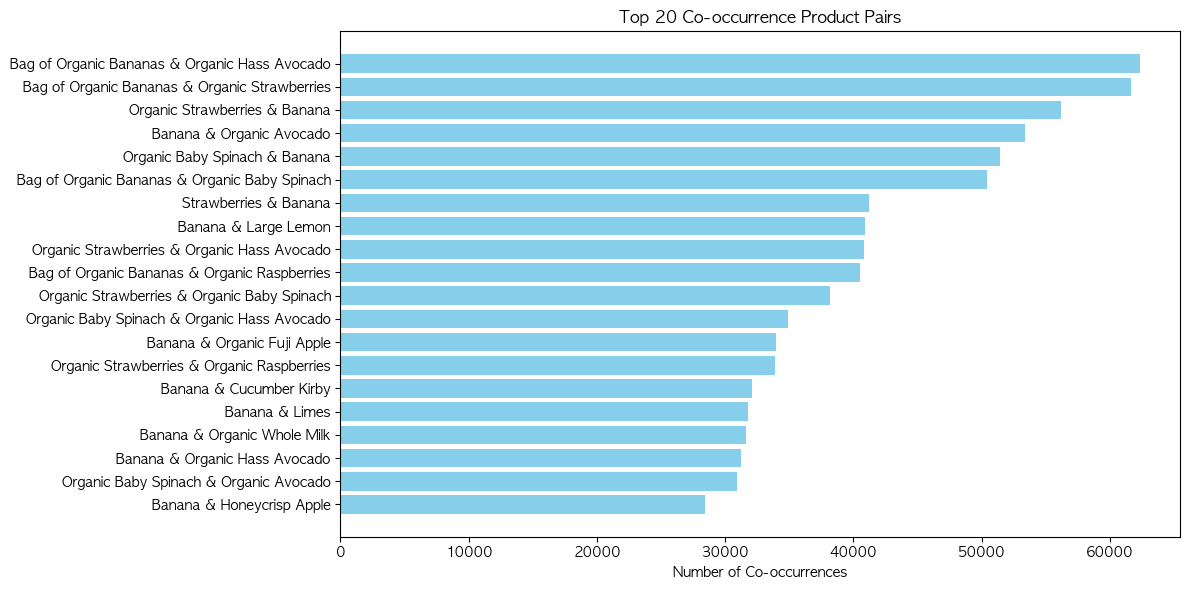

In [22]:
import matplotlib.pyplot as plt

# 1) 데이터 분리
pairs = [f"{p[0]} & {p[1]}" for p, _ in top_pairs_named]
counts = [cnt for _, cnt in top_pairs_named]

# 2) 막대그래프 그리기
plt.figure(figsize=(12, 6))
plt.barh(pairs[::-1], counts[::-1], color='skyblue')
plt.xlabel('Number of Co-occurrences')
plt.title('Top 20 Co-occurrence Product Pairs')
plt.tight_layout()
plt.show()


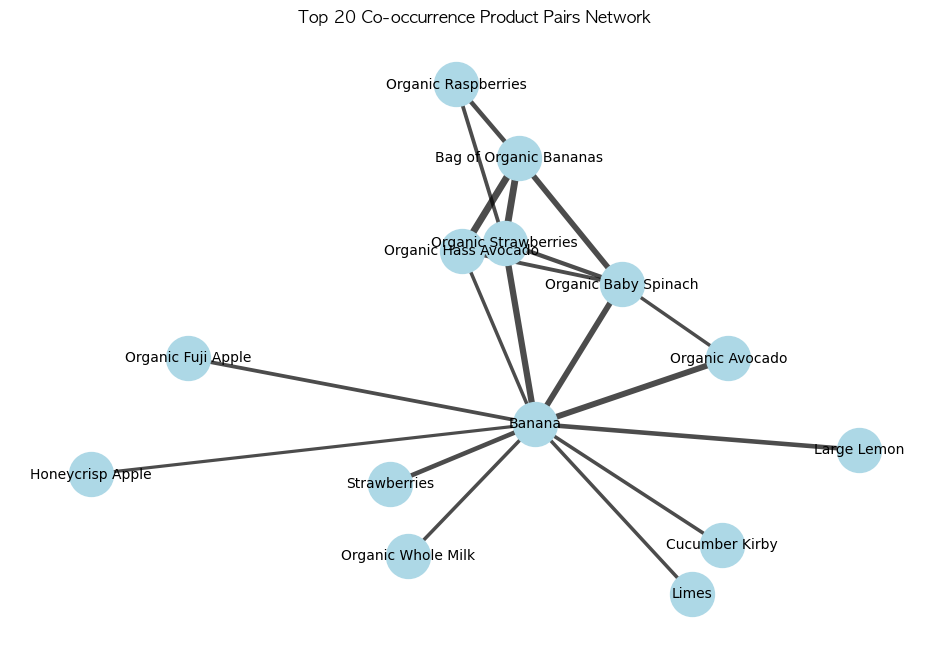

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

# 1) 네트워크 그래프 생성
G = nx.Graph()

# 2) 노드(상품)와 엣지(같이 구매된 횟수) 추가
for (prod1, prod2), count in top_pairs_named:
    G.add_edge(prod1, prod2, weight=count)

# 3) 그래프 레이아웃 설정 (spring layout 추천)
pos = nx.spring_layout(G, k=0.5, iterations=50)

# 4) 엣지 두께에 같이 구매 횟수 반영
edges = G.edges(data=True)
weights = [edata['weight'] for _, _, edata in edges]

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=[w / max(weights) * 5 for w in weights], alpha=0.7)

plt.title('Top 20 Co-occurrence Product Pairs Network')
plt.axis('off')
plt.show()


In [32]:
###  Association Rule (Apriori) 기반 연관 규칙 분석

import pandas as pd
from collections import Counter
from itertools import combinations

# (1) 데이터 준비: orders_df, prior_df, products 필요
# orders_df: order_id, user_id 포함
# prior_df: order_id, product_id 포함
# products: product_id, product_name 포함

# (2) 인기 상품 상위 200개 추출 (유지)
top_products = (
    prior_df['product_id']
    .value_counts()
    .head(200)
    .index
)

# (3) prior_df에서 상위 200개 상품에 해당하는 주문만 필터링 (user 제한 X)
sample_prior = prior_df[
    prior_df['product_id'].isin(top_products)
]

# (4) 주문별 상품 리스트 생성
order_products = sample_prior.groupby('order_id')['product_id'].apply(list)


# (5) 주문별 상품 리스트 생성
order_products = sample_prior.groupby('order_id')['product_id'].apply(list)

# (6) 상품쌍 동시 출현 카운트
pair_counter = Counter()
for products in order_products:
    unique_products = sorted(set(products))
    pairs = combinations(unique_products, 2)
    pair_counter.update(pairs)

# (7) 상위 30개 같이 구매된 상품쌍
top_pairs = pair_counter.most_common(30)

# (8) product_id → product_name 매핑
product_name_map = dict(zip(prior_df['product_id'], prior_df['product_name']))

# (9) 결과 보기
top_pairs_named = [((product_name_map.get(p1, p1), product_name_map.get(p2, p2)), count)
                   for (p1, p2), count in top_pairs]

# (10) 출력
for (p1, p2), count in top_pairs_named:
    print(f"{p1} & {p2}: {count}번 같이 구매됨")


Bag of Organic Bananas & Organic Hass Avocado: 62341번 같이 구매됨
Bag of Organic Bananas & Organic Strawberries: 61628번 같이 구매됨
Organic Strawberries & Banana: 56156번 같이 구매됨
Banana & Organic Avocado: 53395번 같이 구매됨
Organic Baby Spinach & Banana: 51395번 같이 구매됨
Bag of Organic Bananas & Organic Baby Spinach: 50372번 같이 구매됨
Strawberries & Banana: 41232번 같이 구매됨
Banana & Large Lemon: 40880번 같이 구매됨
Organic Strawberries & Organic Hass Avocado: 40794번 같이 구매됨
Bag of Organic Bananas & Organic Raspberries: 40503번 같이 구매됨
Organic Strawberries & Organic Baby Spinach: 38134번 같이 구매됨
Organic Baby Spinach & Organic Hass Avocado: 34901번 같이 구매됨
Banana & Organic Fuji Apple: 33943번 같이 구매됨
Organic Strawberries & Organic Raspberries: 33863번 같이 구매됨
Banana & Cucumber Kirby: 32097번 같이 구매됨
Banana & Limes: 31772번 같이 구매됨
Banana & Organic Whole Milk: 31641번 같이 구매됨
Banana & Organic Hass Avocado: 31222번 같이 구매됨
Organic Baby Spinach & Organic Avocado: 30889번 같이 구매됨
Banana & Honeycrisp Apple: 28408번 같이 구매됨
Limes & Large Lemon: 274

In [40]:
# (1) 인기 상품 상위 200개 추출 (전체)
top_products = prior_df['product_id'].value_counts().head(200).index

# (2) prior_df에서 인기 상품 필터링 + 특정 카테고리만 필터링 ('produce' 예시)
category = 'milk'  # 바꾸고 싶은 카테고리명
category_products = prior_df[prior_df['aisle'] == category]['product_id'].unique()

filtered_products = set(top_products) & set(category_products)

# (3) prior_df에서 카테고리 + 인기 상품 필터링
sample_prior_cat = prior_df[
    (prior_df['product_id'].isin(filtered_products))
]

# (4) 주문별 상품 리스트 생성
order_products_cat = sample_prior_cat.groupby('order_id')['product_id'].apply(list)

# (5) 상품쌍 카운트 (기존 방식)
pair_counter_cat = Counter()
for products in order_products_cat:
    unique_products = sorted(set(products))
    pairs = combinations(unique_products, 2)
    pair_counter_cat.update(pairs)

# (6) 상위 30개 추출
top_pairs_cat = pair_counter_cat.most_common(30)

# (7) product_id → product_name 매핑 (기존 변수 재사용 가능)
top_pairs_cat_named = [((product_name_map.get(p1, p1), product_name_map.get(p2, p2)), count)
                      for (p1, p2), count in top_pairs_cat]

# (8) 출력
print(f"Top product pairs in category '{category}':")
for (p1, p2), count in top_pairs_cat_named:
    print(f"{p1} & {p2}: {count}번 같이 구매됨")


Top product pairs in category 'milk':
Organic Whole Milk & Organic Reduced Fat Milk: 2910번 같이 구매됨
Organic Milk & Organic Reduced Fat 2% Milk: 2338번 같이 구매됨
Organic Whole Milk & Organic Fat Free Milk: 2095번 같이 구매됨
Organic Reduced Fat 2% Milk & Organic Fat Free Milk: 1845번 같이 구매됨
Whole Milk & 2% Reduced Fat Milk: 1559번 같이 구매됨
Whole Milk & Fat Free Milk: 1357번 같이 구매됨
Organic Milk & Organic Fat Free Milk: 1091번 같이 구매됨
Fat Free Milk & Organic Whole Milk: 1011번 같이 구매됨
Fat Free Milk & 2% Reduced Fat Milk: 993번 같이 구매됨
Organic 2% Reduced Fat Milk & Organic Whole Milk: 885번 같이 구매됨
Organic Reduced Fat 2% Milk & Organic Whole Milk: 821번 같이 구매됨
Organic Fat Free Milk & Organic Reduced Fat Milk: 584번 같이 구매됨
Organic Reduced Fat 2% Milk & Milk, Organic, Vitamin D: 498번 같이 구매됨
Organic Milk & Milk, Organic, Vitamin D: 328번 같이 구매됨
Milk, Organic, Vitamin D & Organic Fat Free Milk: 316번 같이 구매됨
2% Reduced Fat Milk & Organic Whole Milk: 247번 같이 구매됨
Organic 2% Reduced Fat Milk & Organic Fat Free Milk: 190번 같이 구

In [46]:
import networkx as nx

# (1) 그래프 생성
G_cat = nx.Graph()

for (p1, p2), count in top_pairs_cat:
    name1 = product_name_map.get(p1, str(p1))
    name2 = product_name_map.get(p2, str(p2))
    G_cat.add_edge(name1, name2, weight=count)


# Degree centrality (가장 단순)
degree_centrality = nx.degree_centrality(G_cat)

# Betweenness centrality (중개자 역할)
betweenness_centrality = nx.betweenness_centrality(G_cat)

# Closeness centrality (네트워크 내 평균 거리)
closeness_centrality = nx.closeness_centrality(G_cat)


def print_top_centrality(centrality_dict, name):
    sorted_centrality = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)
    print(f"\nTop 5 products by {name}:")
    for product, score in sorted_centrality[:5]:
        print(f"{product}: {score:.4f}")

print_top_centrality(degree_centrality, 'Degree Centrality')
print_top_centrality(betweenness_centrality, 'Betweenness Centrality')
print_top_centrality(closeness_centrality, 'Closeness Centrality')



Top 5 products by Degree Centrality:
Organic Whole Milk: 1.0000
Organic Fat Free Milk: 0.8889
Fat Free Milk: 0.7778
Organic Reduced Fat Milk: 0.6667
Organic Reduced Fat 2% Milk: 0.6667

Top 5 products by Betweenness Centrality:
Organic Whole Milk: 0.1667
Organic Fat Free Milk: 0.0856
Fat Free Milk: 0.0556
Whole Milk: 0.0301
Organic Reduced Fat Milk: 0.0278

Top 5 products by Closeness Centrality:
Organic Whole Milk: 1.0000
Organic Fat Free Milk: 0.9000
Fat Free Milk: 0.8182
Organic Reduced Fat Milk: 0.7500
Organic Reduced Fat 2% Milk: 0.7500


Organic Whole Milk는 네트워크에서 가장 중심적이고, 많은 연관성을 가지며, 네트워크 구조에서 중요한 역할을 하는 핵심 상품임
Organic Fat Free Milk, Fat Free Milk, Organic Reduced Fat Milk 등도 비슷하게 주요한 역할을 하며, 유제품 카테고리에서 중심 상품들로 보임.
이런 중심 상품들을 기준으로 연관 상품을 추천하면 어떨까 싶음 ..!!

In [48]:
!pip install python-louvain
import community as community_louvain

# (1) 그래프 G_cat이 준비된 상태에서
partition = community_louvain.best_partition(G_cat)

# (2) 노드별 커뮤니티 번호 확인
from collections import defaultdict
communities = defaultdict(list)
for node, comm_id in partition.items():
    communities[comm_id].append(node)

# (3) 커뮤니티별 노드 출력 (상위 3개만)
for comm_id, nodes in list(communities.items())[:3]:
    print(f"\nCommunity {comm_id} ({len(nodes)} nodes):")
    print(nodes)


  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9388 sha256=e8b0556e8f26dbd948c1b195af70b20f2e975b288bc400dc494c5f7a92b49b81
  Stored in directory: /Users/jeonseoyeong/Library/Caches/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain

Community 1 (3 nodes):
['Organic Whole Milk', 'Organic Reduced Fat Milk', 'Organic 2% Reduced Fat Milk']

Community 0 (4 nodes):
['Organic Milk', 'Organic Reduced Fat 2% Milk', 'Organic Fat Free Milk', 'Milk, Organic, Vitamin D']

Community 2 (3 nodes):
['Whole Milk', '2% Reduced Fat Milk', 'Fat Free Milk']


/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_20429/2559319753.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', max(colors) + 1)


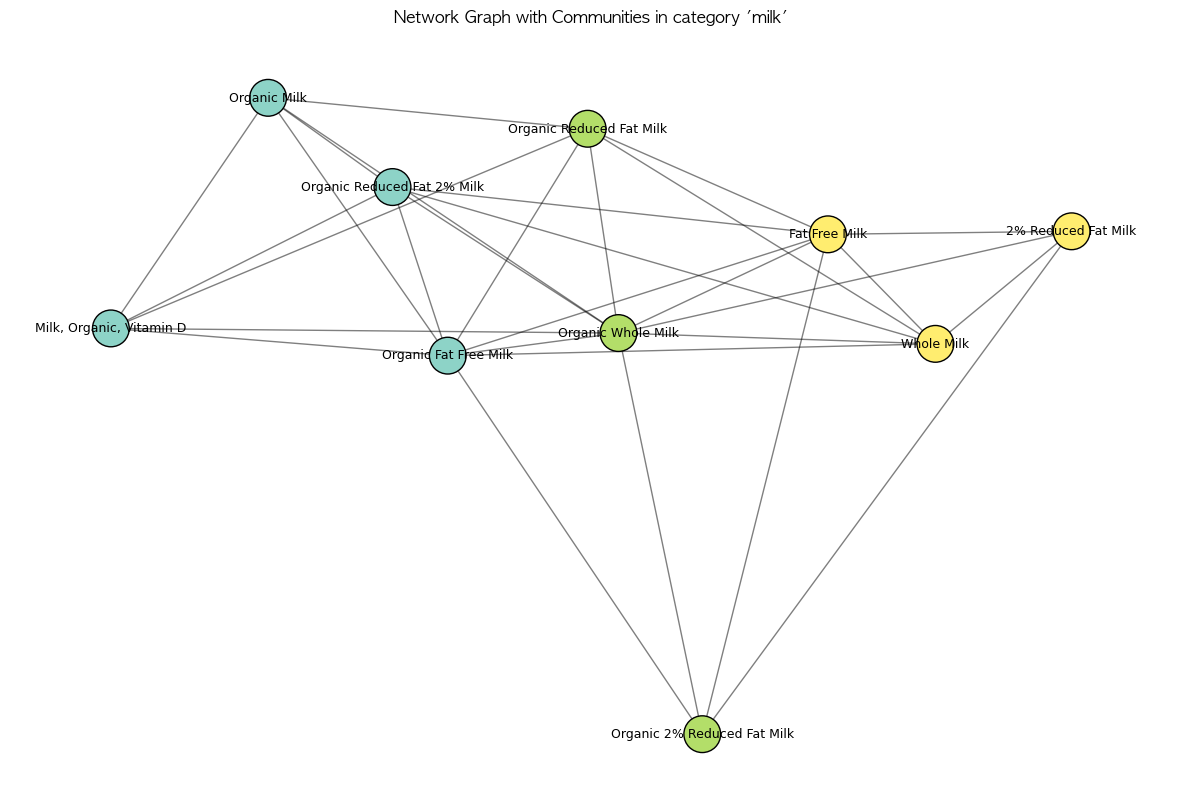

In [50]:
import matplotlib.pyplot as plt

# (1) 커뮤니티 별 색상 지정
colors = [partition[node] for node in G_cat.nodes()]
cmap = plt.cm.get_cmap('Set3', max(colors) + 1)

# (2) 그래프 그리기
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G_cat, k=0.5, seed=42)

nx.draw_networkx_nodes(G_cat, pos, node_size=700, node_color=colors, cmap=cmap, edgecolors='black')
nx.draw_networkx_edges(G_cat, pos, alpha=0.5)
nx.draw_networkx_labels(G_cat, pos, font_size=9)

plt.title(f"Network Graph with Communities in category '{category}'")
plt.axis('off')
plt.show()


/var/folders/f4/1y5qvmvd5v514kbpgr0p58440000gn/T/ipykernel_20429/3519995865.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cat_color_map = {cat: plt.cm.get_cmap('tab20')(i) for i, cat in enumerate(categories_unique)}


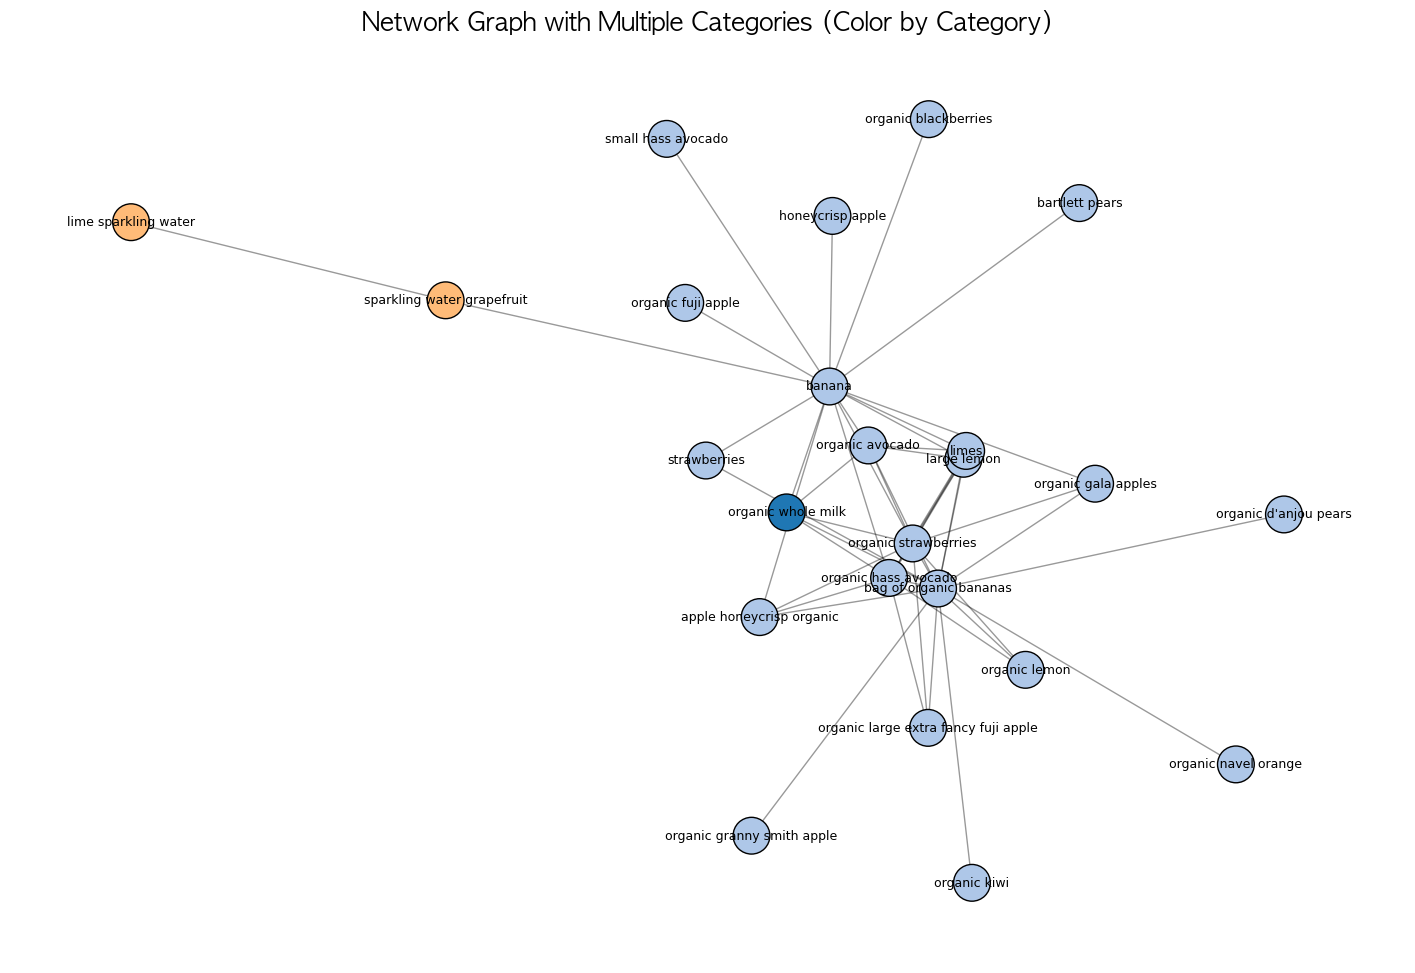

In [56]:
## 너무 우유 제품에만 집중되어 있어서 다른 카테고리도 포함해서 탐색

#1. 여러 카테고리별 커뮤니티 탐색 & 네트워크 시각화 with 카테고리별 색깔


import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

# 1) 카테고리 리스트 지정 (aisle명 정확히 맞춰야 함)
categories = ['milk', 'water seltzer sparkling water', 'fresh fruits', 'eggs']

# 2) 각 카테고리별 인기 상품 100개씩 뽑아서 합치기
top_products_multi = []
for cat in categories:
    top_p = prior_df[prior_df['aisle'] == cat]['product_id'].value_counts().head(100).index.tolist()
    top_products_multi.extend(top_p)
top_products_multi = list(set(top_products_multi))

# 3) prior_df에서 인기 상품 필터링
sample_prior_multi = prior_df[
    prior_df['product_id'].isin(top_products_multi)
].copy()

# 4) 상품명 클린업 (소문자, 공백 제거)
sample_prior_multi['product_name_clean'] = sample_prior_multi['product_name'].str.lower().str.strip()

# 5) 상품별 카테고리 매핑 (클린한 상품명 기준)
product_category_map = dict(sample_prior_multi[['product_name_clean', 'aisle']].drop_duplicates().values)

# 6) 주문별 상품 리스트 생성 (클린한 이름 사용)
order_products_multi = sample_prior_multi.groupby('order_id')['product_name_clean'].apply(list)

# 7) 상품쌍 카운트
pair_counter_multi = Counter()
for products in order_products_multi:
    unique_products = sorted(set(products))
    pairs = combinations(unique_products, 2)
    pair_counter_multi.update(pairs)

top_pairs_multi = pair_counter_multi.most_common(50)

# 8) 그래프 생성
G_multi = nx.Graph()
for (p1, p2), count in top_pairs_multi:
    G_multi.add_edge(p1, p2, weight=count)

# 9) 카테고리별 색상 맵핑 준비
categories_unique = list(set(product_category_map.values()))
cat_color_map = {cat: plt.cm.get_cmap('tab20')(i) for i, cat in enumerate(categories_unique)}

# 10) 노드별 색상 리스트 생성
node_colors_multi = [cat_color_map.get(product_category_map.get(node, ''), (0.5, 0.5, 0.5)) for node in G_multi.nodes()]

# 11) 네트워크 시각화
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G_multi, k=0.6, seed=42)
nx.draw_networkx_nodes(G_multi, pos, node_size=700, node_color=node_colors_multi, edgecolors='black')
nx.draw_networkx_edges(G_multi, pos, alpha=0.4)
nx.draw_networkx_labels(G_multi, pos, font_size=9)
plt.title("Network Graph with Multiple Categories (Color by Category)", fontsize=18)
plt.axis('off')
plt.show()



In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# orders 테이블 기준
avg_days = prior_df.groupby('user_id')['days_since_prior_order'].mean().reset_index()
avg_days.columns = ['user_id', 'avg_days_between_orders']

#2. 평균 장바구니 크기 (avg_cart_size)
cart_size = prior_df.groupby(['user_id', 'order_id'])['product_id'].count().reset_index()
avg_cart = cart_size.groupby('user_id')['product_id'].mean().reset_index()
avg_cart.columns = ['user_id', 'avg_cart_size']


#3. 구매한 카테고리 다양성 (n_unique_departments)

n_dept = prior_df.groupby('user_id')['department_id'].nunique().reset_index()
n_dept.columns = ['user_id', 'n_unique_departments']



rfm_df = rfm.merge(avg_days, on='user_id', how='left')
rfm_df = rfm_df.merge(avg_cart, on='user_id', how='left')
rfm_df = rfm_df.merge(n_dept, on='user_id', how='left')


In [75]:
rfm_df

,user_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Segment,cluster,avg_days_between_orders,avg_cart_size,n_unique_departments
0,1,189.0,10,0.694915,2,2,3,7,223,2,18.542373,5.900000,7
1,2,167.0,14,0.476923,3,2,2,7,322,2,14.902564,13.928571,13
2,3,232.0,12,0.625000,2,2,3,7,223,2,10.181818,7.333333,9
3,4,310.0,5,0.055556,1,1,1,3,111,0,11.944444,3.600000,9
4,5,325.0,4,0.378378,1,1,2,4,112,0,10.189189,9.250000,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
206204,206205,325.0,3,0.250000,1,1,1,3,111,0,9.687500,10.666667,9
206205,206206,116.0,67,0.473684,3,3,2,8,332,1,3.985965,4.253731,16
206206,206207,150.0,16,0.587444,3,3,3,9,333,2,13.278027,13.937500,14
206207,206208,8.0,49,0.707533,3,3,3,9,333,1,7.310192,13.816327,17


In [78]:
from sklearn.preprocessing import StandardScaler

X = rfm_df[['Recency', 'Frequency', 'avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_df['cluster_v2'] = kmeans.fit_predict(X_scaled)

rfm_df.groupby('cluster_v2')[['Recency', 'Frequency', 'avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']].mean().round(2)


,Recency,Frequency,avg_days_between_orders,avg_cart_size,n_unique_departments
cluster_v2,,,,,
0,229.26,10.08,14.37,14.21,12.90
1,62.14,41.22,8.79,10.10,13.83
2,265.46,7.51,13.92,5.85,7.31


In [80]:
from sklearn.preprocessing import StandardScaler

X = rfm_df[['Recency', 'Frequency', 'Monetary', 'avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_df['cluster_v2'] = kmeans.fit_predict(X_scaled)

rfm_df.groupby('cluster_v2')[['Recency', 'Frequency','Monetary', 'avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']].mean().round(2)


,Recency,Frequency,Monetary,avg_days_between_orders,avg_cart_size,n_unique_departments
cluster_v2,,,,,,
0,229.22,9.99,0.39,14.43,14.18,12.95
1,272.41,6.83,0.33,14.02,6.02,7.40
2,68.97,39.12,0.66,9.12,10.16,13.41


In [82]:
from sklearn.preprocessing import StandardScaler

X = rfm_df[['Recency', 'Frequency', 'Monetary', 'avg_days_between_orders']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_df['cluster_v2'] = kmeans.fit_predict(X_scaled)

rfm_df.groupby('cluster_v2')[['Recency', 'Frequency','Monetary', 'avg_days_between_orders']].mean().round(2)


,Recency,Frequency,Monetary,avg_days_between_orders
cluster_v2,,,,
0,297.02,7.61,0.34,9.02
1,76.01,36.70,0.66,9.59
2,224.47,8.19,0.35,18.50


In [86]:
from sklearn.preprocessing import StandardScaler

X = rfm_df[['Recency', 'Frequency', 'Monetary', 'avg_cart_size']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_df['cluster_v2'] = kmeans.fit_predict(X_scaled)

rfm_df.groupby('cluster_v2')[['Recency', 'Frequency','Monetary', 'avg_cart_size']].mean().round(2)

,Recency,Frequency,Monetary,avg_cart_size
cluster_v2,,,,
0,239.19,9.52,0.44,17.61
1,75.64,35.47,0.65,9.56
2,268.28,7.33,0.31,7.04


In [88]:

from sklearn.preprocessing import StandardScaler

X = rfm_df[['Recency', 'Frequency', 'Monetary', 'n_unique_departments']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_df['cluster_v2'] = kmeans.fit_predict(X_scaled)

rfm_df.groupby('cluster_v2')[['Recency', 'Frequency','Monetary', 'n_unique_departments']].mean().round(2)

,Recency,Frequency,Monetary,n_unique_departments
cluster_v2,,,,
0,179.28,14.68,0.50,12.28
1,46.15,45.74,0.69,13.86
2,292.99,5.34,0.28,8.50


In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def silhouette_compare(rfm_df):
    base_features = ['Recency', 'Frequency', 'Monetary']
    derived_features = ['avg_days_between_orders', 'avg_cart_size', 'n_unique_departments']

    results = {}

    # 기본 RFM만
    X_base = rfm_df[base_features]
    X_base_scaled = StandardScaler().fit_transform(X_base)
    kmeans_base = KMeans(n_clusters=3, random_state=42)
    labels_base = kmeans_base.fit_predict(X_base_scaled)
    score_base = silhouette_score(X_base_scaled, labels_base)
    results['RFM only'] = score_base

    # 파생변수 하나씩 추가
    for feature in derived_features:
        features = base_features + [feature]
        X = rfm_df[features]
        X_scaled = StandardScaler().fit_transform(X)
        kmeans = KMeans(n_clusters=3, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        results[f'RFM + {feature}'] = score

    # 결과 출력
    for k, v in results.items():
        print(f"{k}: Silhouette Score = {v:.4f}")

    return results

# 사용 예시
silhouette_compare(rfm_df)


RFM only: Silhouette Score = 0.4188
RFM + avg_days_between_orders: Silhouette Score = 0.3342
RFM + avg_cart_size: Silhouette Score = 0.3211
RFM + n_unique_departments: Silhouette Score = 0.3100


{'RFM only': 0.4187677664630298,
 'RFM + avg_days_between_orders': 0.3341677349108523,
 'RFM + avg_cart_size': 0.3210555765531361,
 'RFM + n_unique_departments': 0.3100206169473045}

In [100]:
# 예: 1,500명 랜덤 샘플링
sampled_rfm = rfm[['Recency', 'Frequency', 'Monetary']].sample(n=10000, random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
sampled_scaled = scaler.fit_transform(sampled_rfm)

# GMM 클러스터링 실험
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for n in range(2, 7):
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(sampled_scaled)
    score = silhouette_score(sampled_scaled, labels)
    silhouette_scores[n] = score
    print(f"GMM Clusters: {n} | Silhouette Score: {score:.4f}")



GMM Clusters: 2 | Silhouette Score: 0.4520
GMM Clusters: 3 | Silhouette Score: 0.3417
GMM Clusters: 4 | Silhouette Score: 0.2484
GMM Clusters: 5 | Silhouette Score: 0.1602
GMM Clusters: 6 | Silhouette Score: 0.1887
